# Customer Churn Analytics & Retention Strategy Using Python, SQL and Power BI

## Project Overview
This end-to-end Data Analyst portfolio project uses the IBM Cell2Cell telecommunications dataset to analyse customer churn, identify churn drivers, quantify revenue at risk, prioritise customers for retention, compare five machine-learning classification models, and deliver interactive reporting through Power BI. 
The five evaluated models are Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbours and XGBoost.

## Business Problem
Cell2Cell is losing customers and recurring revenue through churn. The business needs to understand which customer groups are leaving, which service and usage factors are associated with churn, how much revenue is affected, and which active customers should be prioritised for retention.

### Business Questions
1. What is the overall churn rate?
2. Which customer segments have the highest churn?
3. How do tenure, care calls, usage changes, overage, device age and service quality relate to churn?
4. How much monthly and annualised revenue is associated with churned customers?
5. Which active customers should be prioritised for retention?
6. What business actions may reduce churn?

## Notebook Review Notes

This reviewed version keeps the original business analysis and corrects several portfolio-quality issues:

- The rule-based frustration risk signal now selects only the highest frustration quartile.
- Potential post-intervention leakage fields are excluded from machine-learning inputs.
- Dataset-wide quantile-derived features are excluded from the model to reduce leakage.
- One-hot encoding remains sparse to reduce memory usage.
- Test predictions retain the customer identifier for traceability.
- Additional SQL and retention summary outputs are exported.

The Logistic Regression model remains a baseline and its moderate performance should be reported honestly.


## Step 1. Install Required Packages

We install packages for data preparation, visualisation, SQL, machine learning, Excel export and model storage.

**Why:** These tools are not all included with Python by default. Run this cell only when the packages are not already installed.

In [4]:
%pip install pandas numpy matplotlib seaborn plotly duckdb scikit-learn missingno openpyxl joblib


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2. Import Libraries and Configure the Notebook

We import the required libraries and set display, chart and reproducibility options.

**Why:** Importing makes the installed packages available in the notebook. A fixed random state helps produce repeatable model results.

In [7]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import duckdb
import missingno as msno

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## Step 3. Create Project Folders

We create folders for raw data, processed data, charts, tables and models.

**Why:** A clear folder structure keeps the project organised and ready for GitHub or portfolio use.

In [9]:
BASE_DIR = Path.cwd()
RAW_DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = BASE_DIR / "models"

for folder in [RAW_DATA_DIR, PROCESSED_DATA_DIR, OUTPUT_DIR, CHART_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders created.")

Project folders created.


## Step 4. Load the Dataset

We load `cell2celltrain.csv` into a pandas DataFrame.

**Why:** The data must be in memory before it can be inspected, cleaned or analysed. Place the CSV beside the notebook or inside `data/raw/`.

In [11]:
possible_paths = [
    BASE_DIR / "cell2celltrain.csv",
    RAW_DATA_DIR / "cell2celltrain.csv"
]
data_path = next((p for p in possible_paths if p.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Place 'cell2celltrain.csv' beside this notebook or inside data/raw/."
    )

df_raw = pd.read_csv(data_path, low_memory=False)
print(f"Loaded: {data_path}")
print(f"Shape: {df_raw.shape}")

Loaded: C:\Users\suhan\Project\Customer Churn Prediction\cell2celltrain.csv
Shape: (51047, 58)


## Step 5. Preview and Understand the Dataset

We inspect sample rows, dimensions, column names, data types and summary statistics.

**Why:** This confirms that the file loaded correctly and helps us understand the dataset before changing it.

In [13]:
display(df_raw.head())
print("Shape:", df_raw.shape)
display(pd.DataFrame({"Column": df_raw.columns}))
display(df_raw.dtypes.rename("DataType").reset_index().rename(columns={"index":"Column"}))
display(df_raw.describe(include="all").T)

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.00,22.00,0.25,0.00,0.00,-157.00,-19.00,0.70,0.70,6.30,0.00,0.00,97.20,0.00,0.00,58.00,24.00,1.30,0.00,0.30,61,2,1,SEAPOR503,2.00,2.00,361.00,62.00,0.00,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.00,17.00,0.00,0.00,0.00,-4.00,0.00,0.30,0.00,2.70,0.00,0.00,0.00,0.00,0.00,5.00,1.00,0.30,0.00,0.00,58,1,1,PITHOM412,2.00,1.00,1504.00,40.00,42.00,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.00,38.00,0.00,0.00,0.00,-2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.30,0.00,1.30,3.70,0.00,0.00,0.00,60,1,1,MILMIL414,1.00,1.00,1812.00,26.00,26.00,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.00,75.00,1.24,0.00,0.00,157.00,8.10,52.00,7.70,76.00,4.30,1.30,200.30,370.30,147.00,555.70,303.70,59.70,0.00,22.70,59,2,2,PITHOM412,9.00,4.00,458.00,30.00,0.00,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.00,17.00,0.00,0.00,0.00,0.00,-0.20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,53,2,2,OKCTUL918,4.00,3.00,852.00,46.00,54.00,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


Shape: (51047, 58)


,Column
0,CustomerID
1,Churn
2,MonthlyRevenue
3,MonthlyMinutes
4,TotalRecurringCharge
5,DirectorAssistedCalls
6,OverageMinutes
7,RoamingCalls
8,PercChangeMinutes
9,PercChangeRevenues


,Column,DataType
0,CustomerID,int64
1,Churn,object
2,MonthlyRevenue,float64
3,MonthlyMinutes,float64
4,TotalRecurringCharge,float64
5,DirectorAssistedCalls,float64
6,OverageMinutes,float64
7,RoamingCalls,float64
8,PercChangeMinutes,float64
9,PercChangeRevenues,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,51047.00,NaN,NaN,NaN,3201956.88,116905.56,3000002.00,3100632.00,3201534.00,3305376.00,3399994.00
Churn,51047,2,No,36336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyRevenue,50891.00,NaN,NaN,NaN,58.83,44.51,-6.17,33.61,48.46,71.06,1223.38
MonthlyMinutes,50891.00,NaN,NaN,NaN,525.65,529.87,0.00,158.00,366.00,723.00,7359.00
TotalRecurringCharge,50891.00,NaN,NaN,NaN,46.83,23.85,-11.00,30.00,45.00,60.00,400.00
DirectorAssistedCalls,50891.00,NaN,NaN,NaN,0.90,2.23,0.00,0.00,0.25,0.99,159.39
OverageMinutes,50891.00,NaN,NaN,NaN,40.03,96.59,0.00,0.00,3.00,41.00,4321.00
RoamingCalls,50891.00,NaN,NaN,NaN,1.24,9.82,0.00,0.00,0.00,0.30,1112.40
PercChangeMinutes,50680.00,NaN,NaN,NaN,-11.55,257.51,-3875.00,-83.00,-5.00,66.00,5192.00
PercChangeRevenues,50680.00,NaN,NaN,NaN,-1.19,39.57,-1107.70,-7.10,-0.30,1.60,2483.50


## Step 6. Create a Working Copy

We create a copy of the raw dataset.

**Why:** The raw data remains unchanged while all cleaning and transformations are performed on `df`.

In [15]:
df = df_raw.copy()
print("Working copy created.")

Working copy created.


## Step 7. Assess Data Quality

We check missing values, missing percentages, duplicates, unique values and target distribution.

**Why:** These checks reveal issues that could distort analysis or cause model errors.

In [17]:
missing_summary = (
    pd.DataFrame({
        "MissingCount": df.isna().sum(),
        "MissingPercent": df.isna().mean() * 100
    })
    .query("MissingCount > 0")
    .sort_values("MissingPercent", ascending=False)
)
display(missing_summary)
print("Duplicate rows:", df.duplicated().sum())
display(pd.DataFrame({
    "Column": df.columns,
    "UniqueValues": [df[c].nunique(dropna=False) for c in df.columns]
}).sort_values("UniqueValues"))
display(df["Churn"].value_counts(dropna=False).rename_axis("Churn").reset_index(name="Count"))

,MissingCount,MissingPercent
AgeHH2,909,1.78
AgeHH1,909,1.78
PercChangeRevenues,367,0.72
PercChangeMinutes,367,0.72
MonthlyRevenue,156,0.31
MonthlyMinutes,156,0.31
RoamingCalls,156,0.31
OverageMinutes,156,0.31
DirectorAssistedCalls,156,0.31
TotalRecurringCharge,156,0.31


Duplicate rows: 0


,Column,UniqueValues
1,Churn,2
53,MadeCallToRetentionTeam,2
46,NewCellphoneUser,2
47,NotNewCellphoneUser,2
43,HasCreditCard,2
42,OwnsComputer,2
41,NonUSTravel,2
40,OptOutMailings,2
39,RespondsToMailOffers,2
38,BuysViaMailOrder,2


,Churn,Count
0,No,36336
1,Yes,14711


## Step 8. Visualise Missing Values

We display the pattern of missing observations.

**Why:** A visual pattern may reveal whether missing values occur together rather than randomly.

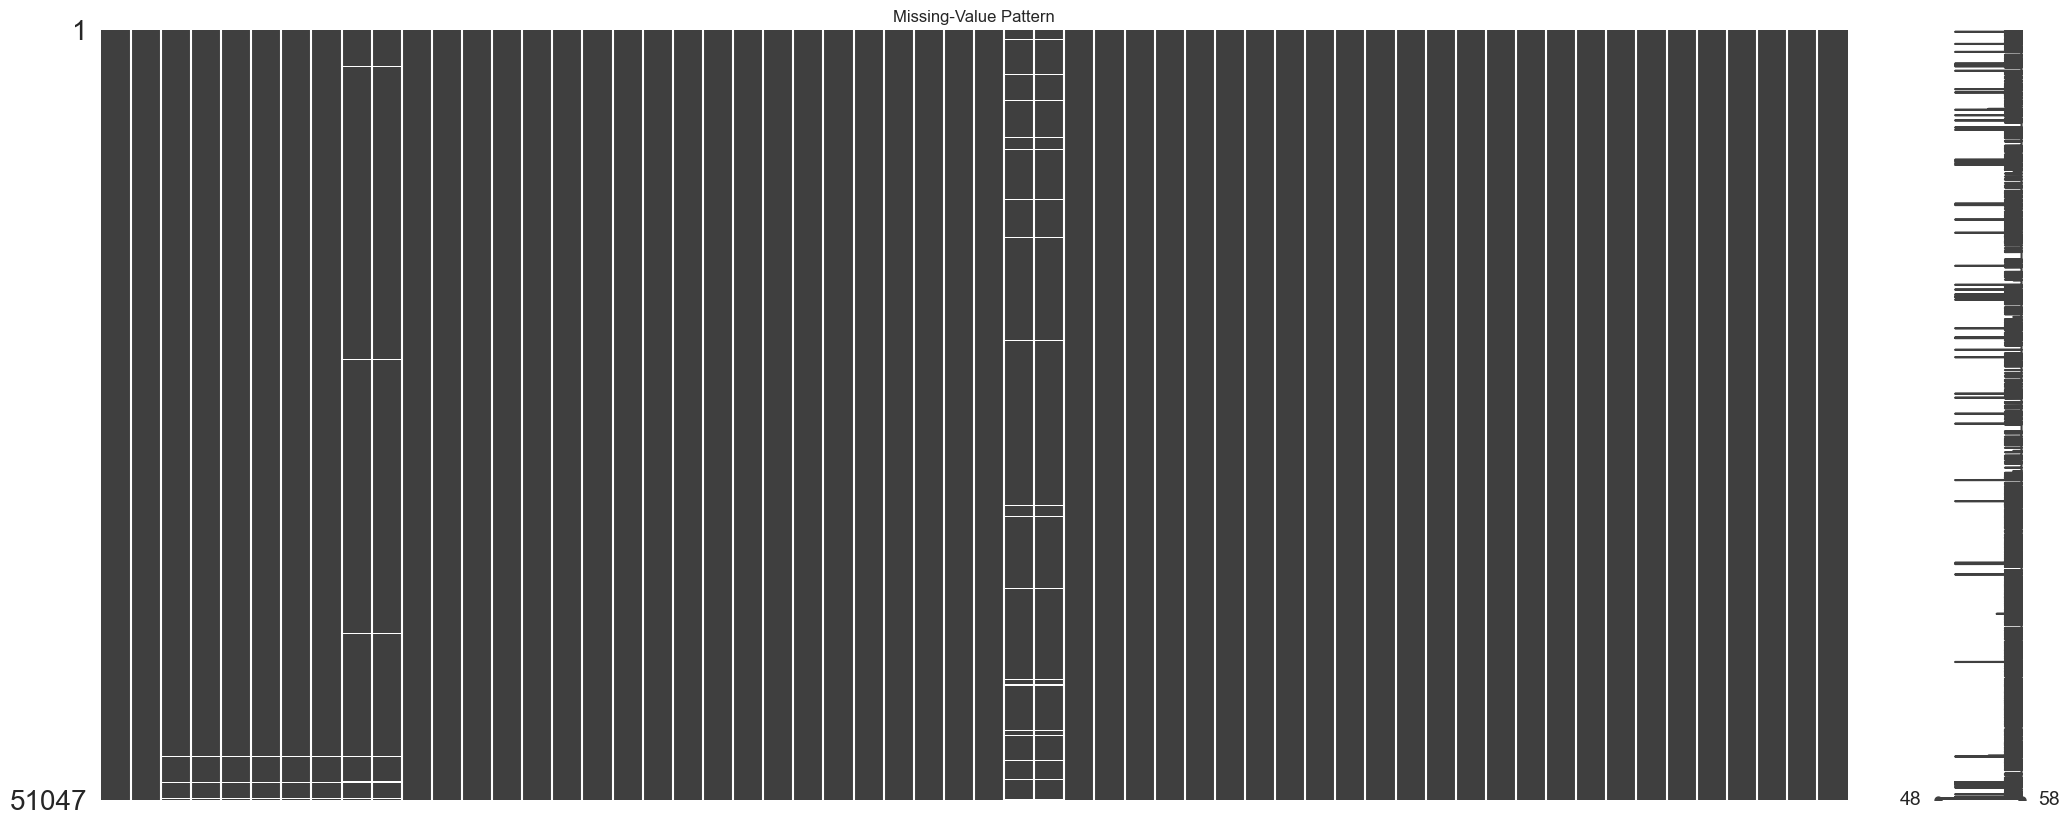

In [19]:
if df.isna().sum().sum() > 0:
    msno.matrix(df)
    plt.title("Missing-Value Pattern")
    plt.show()
else:
    print("No missing values detected.")

## Step 9. Examine Numeric Distributions

We calculate mean, median and skewness and plot selected numeric variables.

**Why:** Skewness helps us choose an appropriate imputation method. Median imputation is usually safer for highly skewed variables.

,Column,Mean,Median,Skewness,MissingCount
20,CallForwardingCalls,0.01,0.00,91.63,0
23,UniqueSubs,1.53,1.00,79.64,0
6,RoamingCalls,1.24,0.00,57.88,156
32,ReferralsMadeBySubscriber,0.05,0.00,36.74,0
34,AdjustmentsToCreditRating,0.05,0.00,18.62,0
13,ThreewayCalls,0.30,0.00,17.55,0
12,CustomerCareCalls,1.87,0.00,14.24,0
4,DirectorAssistedCalls,0.90,0.25,13.57,156
21,CallWaitingCalls,1.84,0.30,11.12,0
24,ActiveSubs,1.35,1.00,10.65,0


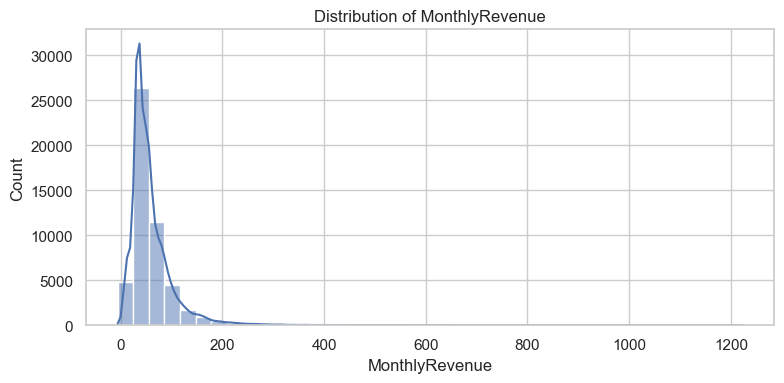

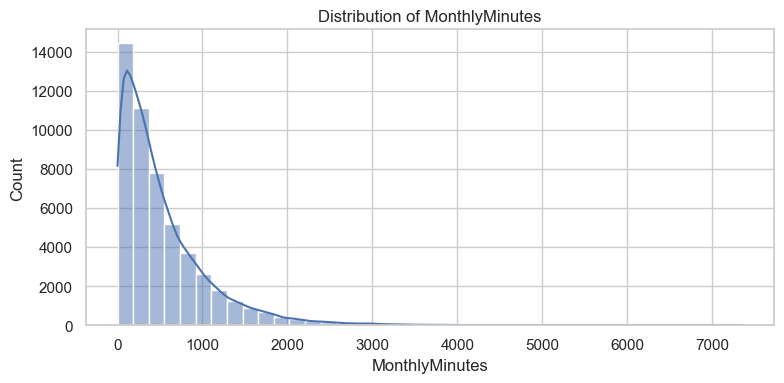

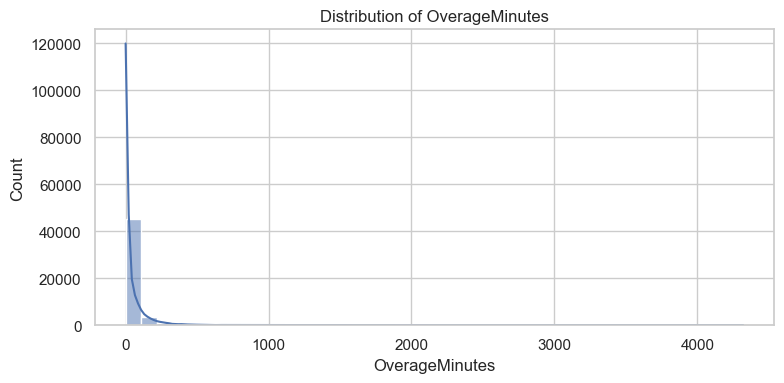

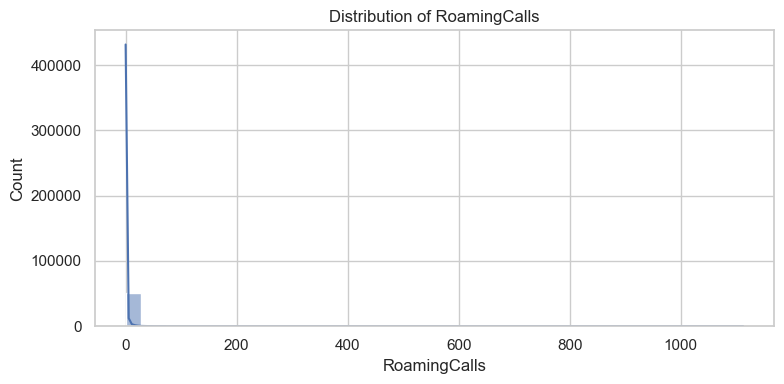

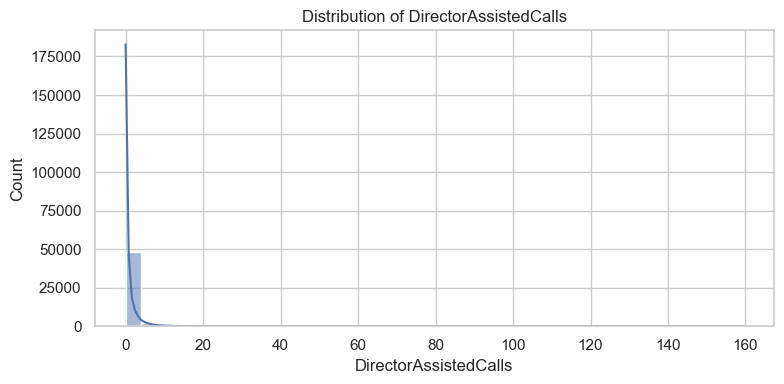

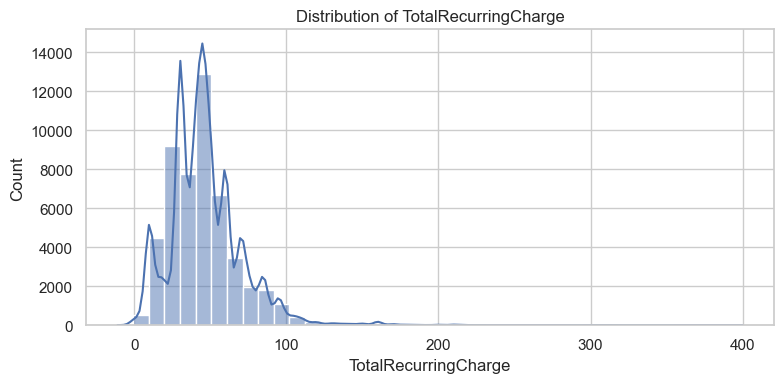

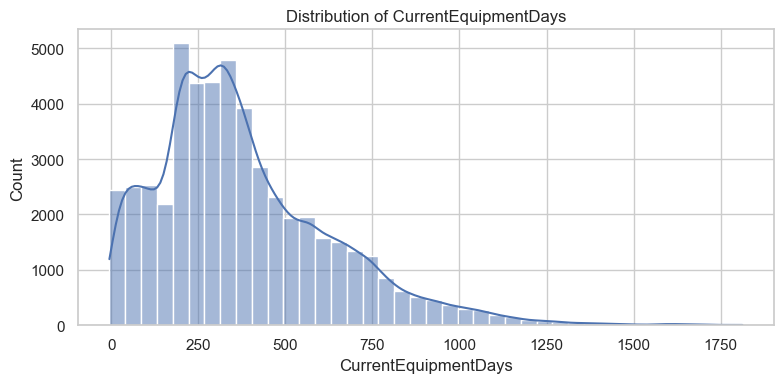

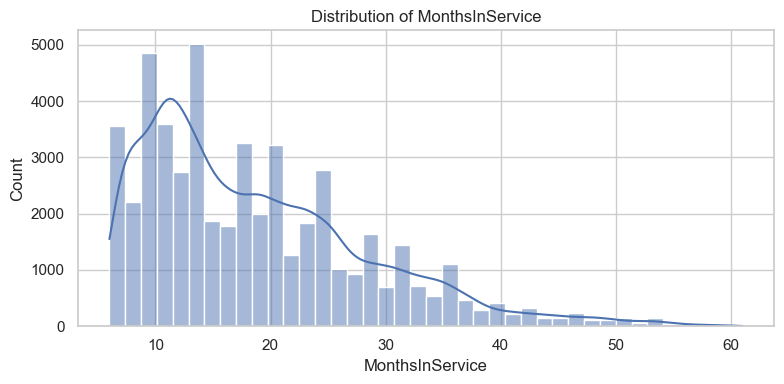

In [21]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
distribution_summary = pd.DataFrame({
    "Column": numeric_columns,
    "Mean": [df[c].mean() for c in numeric_columns],
    "Median": [df[c].median() for c in numeric_columns],
    "Skewness": [df[c].skew() for c in numeric_columns],
    "MissingCount": [df[c].isna().sum() for c in numeric_columns]
}).sort_values("Skewness", key=lambda x: x.abs(), ascending=False)
display(distribution_summary)

plot_columns = [c for c in [
    "MonthlyRevenue","MonthlyMinutes","OverageMinutes","RoamingCalls",
    "DirectorAssistedCalls","TotalRecurringCharge","CurrentEquipmentDays",
    "MonthsInService"
] if c in df.columns]

for col in plot_columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col].dropna(), bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

## Step 10. Remove Duplicate Rows

We remove exact duplicate records.

**Why:** Duplicates can inflate customer, churn and revenue totals.

In [23]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Rows removed:", before - len(df))

Rows removed: 0


## Step 11. Convert Churn to 1 and 0

We convert `Yes` to `1` and `No` to `0`.

**Why:** A numeric target supports churn-rate calculations and machine learning.

In [25]:
if df["Churn"].dtype == "object":
    df["Churn"] = (
        df["Churn"].astype(str).str.strip()
        .map({"Yes": 1, "No": 0})
    )
print("Churn values:", sorted(df["Churn"].dropna().unique()))

Churn values: [np.int64(0), np.int64(1)]


## Step 12. Convert Other Yes/No Columns

We convert other binary text variables to 1 and 0.

**Why:** Numeric binary variables are easier to analyse, correlate and model.

In [27]:
converted_binary_columns = []
for col in df.select_dtypes(include="object").columns:
    values = set(df[col].dropna().astype(str).str.strip().unique())
    if values and values.issubset({"Yes","No"}):
        df[col] = df[col].astype(str).str.strip().map({"Yes":1,"No":0})
        converted_binary_columns.append(col)
print("Converted:", converted_binary_columns)

Converted: ['ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam']


## Step 13. Create Missing-Value Indicators

We record whether selected values were originally missing.

**Why:** After imputation, missingness information would otherwise be lost and may itself be useful.

In [29]:
for col in ["AgeHH2","PercChangeMinutes","PercChangeRevenues"]:
    if col in df.columns:
        df[f"{col}_was_missing"] = df[col].isna().astype(int)
print("Indicators created.")

Indicators created.


## Step 14. Impute Missing Numeric Values

We replace selected missing numeric values with the median.

**Why:** The median retains rows and is less affected by extreme values than the mean.

In [31]:
median_columns = [
    "AgeHH1","MonthlyRevenue","MonthlyMinutes","TotalRecurringCharge",
    "OverageMinutes","RoamingCalls","DirectorAssistedCalls",
    "CurrentEquipmentDays","Handsets","HandsetModels"
]
imputation_log = []
for col in median_columns:
    if col in df.columns:
        count = df[col].isna().sum()
        value = df[col].median()
        df[col] = df[col].fillna(value)
        imputation_log.append([col,"Median",value,count])
display(pd.DataFrame(imputation_log, columns=[
    "Column","Method","ReplacementValue","ValuesReplaced"
]))

,Column,Method,ReplacementValue,ValuesReplaced
0,AgeHH1,Median,36.00,909
1,MonthlyRevenue,Median,48.46,156
2,MonthlyMinutes,Median,366.00,156
3,TotalRecurringCharge,Median,45.00,156
4,OverageMinutes,Median,3.00,156
5,RoamingCalls,Median,0.00,156
6,DirectorAssistedCalls,Median,0.25,156
7,CurrentEquipmentDays,Median,329.00,1
8,Handsets,Median,1.00,1
9,HandsetModels,Median,1.00,1


## Step 15. Handle AgeHH2 Separately

We fill missing `AgeHH2` values using the median of positive ages.

**Why:** Zero may indicate no second household member rather than an actual age.

In [33]:
if "AgeHH2" in df.columns:
    count = df["AgeHH2"].isna().sum()
    replacement = df.loc[df["AgeHH2"] > 0, "AgeHH2"].median()
    df["AgeHH2"] = df["AgeHH2"].fillna(replacement)
    print("AgeHH2 values replaced:", count)
    print("Replacement:", replacement)

AgeHH2 values replaced: 909
Replacement: 44.0


## Step 16. Handle Percentage-Change Variables

We replace missing percentage-change values with zero.

**Why:** Zero represents no recorded change. Indicator columns retain whether the original observation was missing.

In [35]:
for col in ["PercChangeMinutes","PercChangeRevenues"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)
print("Percentage-change variables handled.")

Percentage-change variables handled.


## Step 17. Handle Missing Service Area

We fill missing service areas with the most common category.

**Why:** The mode is appropriate for a categorical variable.

In [37]:
if "ServiceArea" in df.columns:
    mode_value = df["ServiceArea"].mode(dropna=True)[0]
    df["ServiceArea"] = df["ServiceArea"].fillna(mode_value)
    print("ServiceArea replacement:", mode_value)

ServiceArea replacement: NYCBRO917


## Step 18. Validate the Cleaned Dataset

We confirm that missing values and duplicates are gone and that churn contains only 0 and 1.

**Why:** Validation ensures that the dataset is ready for analysis.

In [39]:
assert df.isna().sum().sum() == 0, "Missing values remain."
assert df.duplicated().sum() == 0, "Duplicates remain."
assert set(df["Churn"].unique()).issubset({0,1}), "Unexpected Churn values."
print("Validation passed.")

Validation passed.


## Step 19. Engineer Business Features

We create tenure, usage, care-call, device-age, revenue and overage groups, plus estimated historical lifetime revenue.

**Why:** Business-friendly groups are easier to analyse and communicate in dashboards than raw continuous values.

In [41]:
df["TenureGroup"] = pd.cut(
    df["MonthsInService"], [-np.inf,12,24,48,np.inf],
    labels=["0-12 months","13-24 months","25-48 months","49+ months"]
)
df["UsageTrend"] = pd.cut(
    df["PercChangeMinutes"], [-np.inf,-50,-10,10,50,np.inf],
    labels=["Large decline","Small decline","Stable","Small increase","Large increase"]
)
df["CareCallGroup"] = pd.cut(
    df["CustomerCareCalls"], [-np.inf,0,1,3,6,np.inf],
    labels=["0 calls","1 call","2-3 calls","4-6 calls","7+ calls"]
)
df["DeviceAgeGroup"] = pd.cut(
    df["CurrentEquipmentDays"], [-np.inf,180,365,548,730,np.inf],
    labels=["Under 6 months","6-12 months","12-18 months","18-24 months","Over 2 years"]
)
df["RevenueBand"] = pd.qcut(
    df["MonthlyRevenue"], 4,
    labels=["Low","Medium-low","Medium-high","High"],
    duplicates="drop"
)
df["OverageBand"] = pd.cut(
    df["OverageMinutes"], [-np.inf,0,10,50,100,np.inf],
    labels=["None","Low","Moderate","High","Very high"]
)
df["EstimatedLifetimeRevenue"] = df["MonthlyRevenue"] * df["MonthsInService"]
display(df.head())

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus,AgeHH2_was_missing,PercChangeMinutes_was_missing,PercChangeRevenues_was_missing,TenureGroup,UsageTrend,CareCallGroup,DeviceAgeGroup,RevenueBand,OverageBand,EstimatedLifetimeRevenue
0,3000002,1,24.00,219.00,22.00,0.25,0.00,0.00,-157.00,-19.00,0.70,0.70,6.30,0.00,0.00,97.20,0.00,0.00,58.00,24.00,1.30,0.00,0.30,61,2,1,SEAPOR503,2.00,2.00,361.00,62.00,0.00,0,0,1,0,0,Known,1,1,0,0,1,1,1,0,0,0,0,4,0,0,30,1,1-Highest,Suburban,Professional,No,0,0,0,49+ months,Large decline,0 calls,6-12 months,Low,None,1464.00
1,3000010,1,16.99,10.00,17.00,0.00,0.00,0.00,-4.00,0.00,0.30,0.00,2.70,0.00,0.00,0.00,0.00,0.00,5.00,1.00,0.30,0.00,0.00,58,1,1,PITHOM412,2.00,1.00,1504.00,40.00,42.00,1,0,0,0,0,Known,1,1,0,0,1,1,0,0,1,0,0,5,0,0,30,0,4-Medium,Suburban,Professional,Yes,0,0,0,49+ months,Stable,0 calls,Over 2 years,Low,None,985.42
2,3000014,0,38.00,8.00,38.00,0.00,0.00,0.00,-2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.30,0.00,1.30,3.70,0.00,0.00,0.00,60,1,1,MILMIL414,1.00,1.00,1812.00,26.00,26.00,1,0,0,0,0,Unknown,0,0,0,0,0,1,0,0,1,0,0,6,0,0,Unknown,0,3-Good,Town,Crafts,Yes,0,0,0,49+ months,Stable,0 calls,Over 2 years,Medium-low,None,2280.00
3,3000022,0,82.28,1312.00,75.00,1.24,0.00,0.00,157.00,8.10,52.00,7.70,76.00,4.30,1.30,200.30,370.30,147.00,555.70,303.70,59.70,0.00,22.70,59,2,2,PITHOM412,9.00,4.00,458.00,30.00,0.00,0,0,1,0,0,Known,1,1,0,0,0,1,0,0,1,0,0,6,0,0,10,0,4-Medium,Other,Other,No,0,0,0,49+ months,Large increase,4-6 calls,12-18 months,High,None,4854.52
4,3000026,1,17.14,0.00,17.00,0.00,0.00,0.00,0.00,-0.20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,53,2,2,OKCTUL918,4.00,3.00,852.00,46.00,54.00,0,0,0,0,0,Known,1,1,0,0,1,1,0,0,0,1,0,9,0,1,10,0,1-Highest,Other,Professional,Yes,0,0,0,49+ months,Stable,0 calls,Over 2 years,Low,None,908.42


## Step 20. Create a Frustration Score

We scale and combine available dropped, blocked and unanswered-call variables.

**Why:** Scaling puts different measures on a comparable range. The combined score gives one simple indicator of service difficulty.

In [43]:
frustration_features = [
    c for c in ["DroppedCalls","BlockedCalls","UnansweredCalls"]
    if c in df.columns
]
if frustration_features:
    scaled = MinMaxScaler().fit_transform(df[frustration_features])
    df["FrustrationScore"] = scaled.mean(axis=1) * 100
    df["FrustrationQuartile"] = pd.qcut(
        df["FrustrationScore"].rank(method="first"), 4,
        labels=["Q1 Low","Q2 Medium-low","Q3 Medium-high","Q4 High"]
    )
else:
    df["FrustrationScore"] = 0
    df["FrustrationQuartile"] = "Not available"
print("Features used:", frustration_features)

Features used: ['DroppedCalls', 'BlockedCalls', 'UnansweredCalls']


## Step 21. Calculate Executive KPIs

We calculate customer, churn, retention and revenue KPIs.

**Why:** These measures show the overall scale and financial significance of churn.

In [45]:
total_customers = len(df)
churned_customers = int(df["Churn"].sum())
retained_customers = total_customers - churned_customers
churn_rate = df["Churn"].mean()
monthly_revenue = df["MonthlyRevenue"].sum()
monthly_revenue_lost = df.loc[df["Churn"] == 1, "MonthlyRevenue"].sum()

kpi_summary = pd.DataFrame({
    "KPI":[
        "Total Customers","Churned Customers","Retained Customers",
        "Churn Rate","Retention Rate","Total Monthly Revenue",
        "Monthly Revenue Associated with Churn",
        "Annualised Revenue Associated with Churn"
    ],
    "Value":[
        total_customers,churned_customers,retained_customers,
        churn_rate,1-churn_rate,monthly_revenue,
        monthly_revenue_lost,monthly_revenue_lost*12
    ]
})
display(kpi_summary)

,KPI,Value
0,Total Customers,51047.00
1,Churned Customers,14711.00
2,Retained Customers,36336.00
3,Churn Rate,0.29
4,Retention Rate,0.71
5,Total Monthly Revenue,3001705.91
6,Monthly Revenue Associated with Churn,852497.59
7,Annualised Revenue Associated with Churn,10229971.08


## Step 22. Visualise Churn Distribution

We compare churned and retained customer counts.

**Why:** This summarises the target distribution and reveals class imbalance.

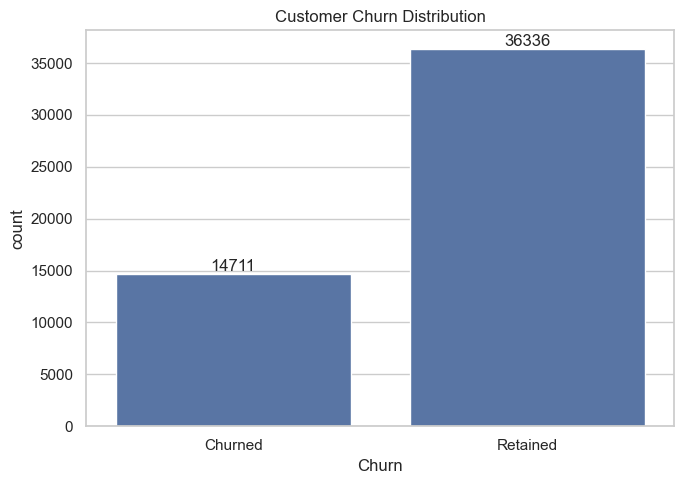

In [47]:
labels = df["Churn"].map({0:"Retained",1:"Churned"})
plt.figure(figsize=(7,5))
ax = sns.countplot(x=labels)
plt.title("Customer Churn Distribution")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(CHART_DIR/"churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 23. Create a Reusable Segment Summary

We define one function for customer count, churn rate and revenue calculations.

**Why:** This avoids repeating the same aggregation code for every segment.

In [49]:
def create_churn_summary(data, group_column):
    result = (
        data.groupby(group_column, observed=False)
        .agg(
            CustomerCount=("Churn","size"),
            ChurnedCustomers=("Churn","sum"),
            ChurnRate=("Churn","mean"),
            AverageMonthlyRevenue=("MonthlyRevenue","mean"),
            TotalMonthlyRevenue=("MonthlyRevenue","sum")
        ).reset_index()
    )
    result["ChurnRatePercent"] = result["ChurnRate"] * 100
    return result

## Step 24: Analyse Churn by Customer Tenure

We calculate and visualise churn across customer tenure groups.

**Why:** This helps identify customer segments with elevated churn and supports targeted retention decisions.

,TenureGroup,CustomerCount,ChurnedCustomers,ChurnRate,AverageMonthlyRevenue,TotalMonthlyRevenue,ChurnRatePercent
0,0-12 months,16975,4520,0.27,59.61,1011814.98,26.63
1,13-24 months,21422,6591,0.31,58.45,1252122.88,30.77
2,25-48 months,12067,3447,0.29,57.91,698823.98,28.57
3,49+ months,583,153,0.26,66.80,38944.07,26.24


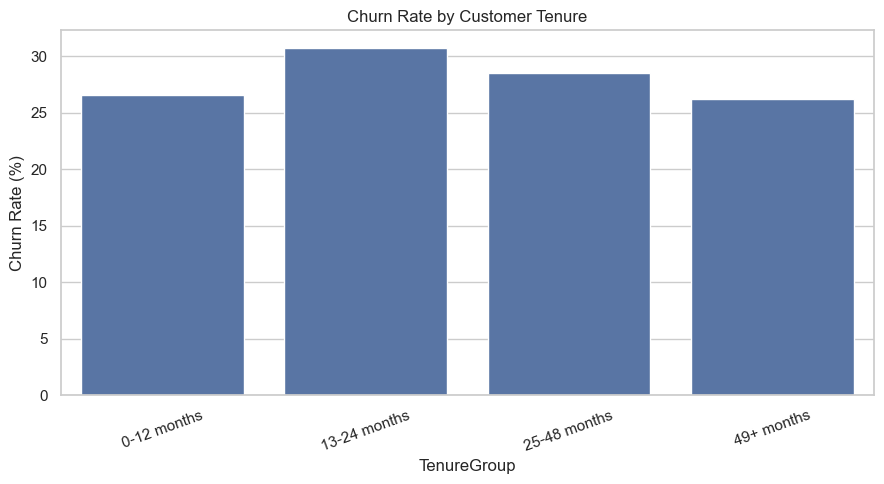

In [51]:
tenure_summary = create_churn_summary(df, "TenureGroup")
display(tenure_summary)
plt.figure(figsize=(9,5))
sns.barplot(data=tenure_summary, x="TenureGroup", y="ChurnRatePercent")
plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_DIR/"churn_by_tenure.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 25: Analyse Churn by Customer-Care Calls

We calculate and visualise churn across customer-care calls groups.

**Why:** This helps identify customer segments with elevated churn and supports targeted retention decisions.

,CareCallGroup,CustomerCount,ChurnedCustomers,ChurnRate,AverageMonthlyRevenue,TotalMonthlyRevenue,ChurnRatePercent
0,0 calls,28020,8609,0.31,48.99,1372571.94,30.72
1,1 call,8134,2339,0.29,63.22,514192.86,28.76
2,2-3 calls,6421,1642,0.26,68.83,441980.61,25.57
3,4-6 calls,3951,1022,0.26,75.36,297751.20,25.87
4,7+ calls,4521,1099,0.24,82.99,375209.30,24.31


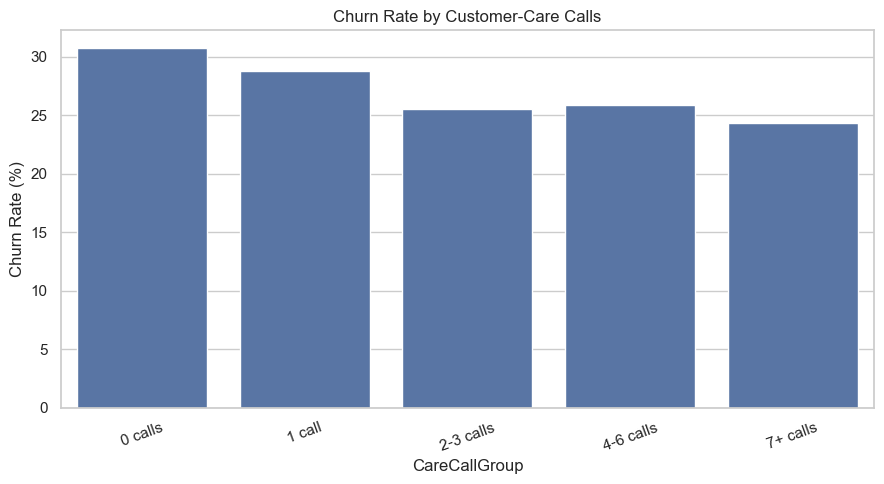

In [53]:
care_summary = create_churn_summary(df, "CareCallGroup")
display(care_summary)
plt.figure(figsize=(9,5))
sns.barplot(data=care_summary, x="CareCallGroup", y="ChurnRatePercent")
plt.title("Churn Rate by Customer-Care Calls")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_DIR/"churn_by_care_calls.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 26: Analyse Churn by Device Age

We calculate and visualise churn across device age groups.

**Why:** This helps identify customer segments with elevated churn and supports targeted retention decisions.

,DeviceAgeGroup,CustomerCount,ChurnedCustomers,ChurnRate,AverageMonthlyRevenue,TotalMonthlyRevenue,ChurnRatePercent
0,Under 6 months,9835,2252,0.23,77.40,761264.88,22.90
1,6-12 months,19085,5077,0.27,59.47,1135074.35,26.60
2,12-18 months,10689,3485,0.33,53.94,576518.32,32.60
3,18-24 months,6297,2042,0.32,49.08,309087.46,32.43
4,Over 2 years,5141,1855,0.36,42.75,219760.90,36.08


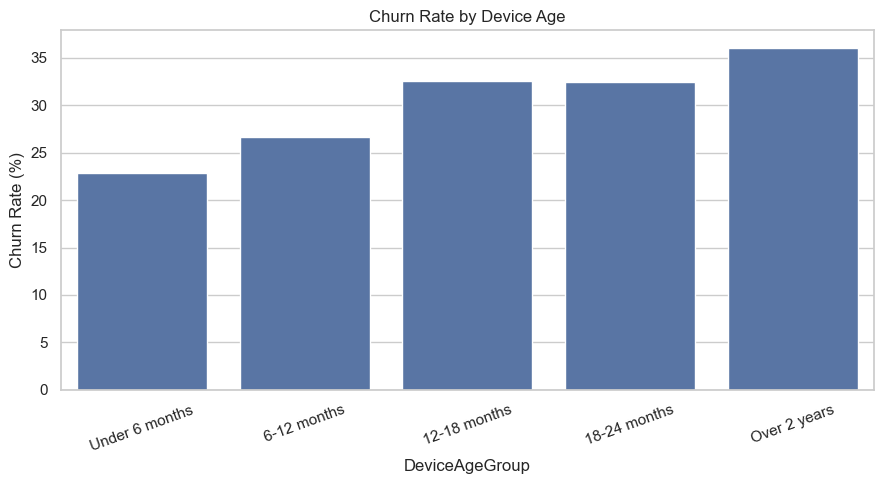

In [55]:
device_summary = create_churn_summary(df, "DeviceAgeGroup")
display(device_summary)
plt.figure(figsize=(9,5))
sns.barplot(data=device_summary, x="DeviceAgeGroup", y="ChurnRatePercent")
plt.title("Churn Rate by Device Age")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_DIR/"churn_by_device_age.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 27: Analyse Churn by Revenue Band

We calculate and visualise churn across revenue band groups.

**Why:** This helps identify customer segments with elevated churn and supports targeted retention decisions.

,RevenueBand,CustomerCount,ChurnedCustomers,ChurnRate,AverageMonthlyRevenue,TotalMonthlyRevenue,ChurnRatePercent
0,Low,12763,4010,0.31,24.68,314969.63,31.42
1,Medium-low,12842,3506,0.27,39.70,509807.97,27.30
2,Medium-high,12681,3634,0.29,57.42,728098.98,28.66
3,High,12761,3561,0.28,113.54,1448829.33,27.91


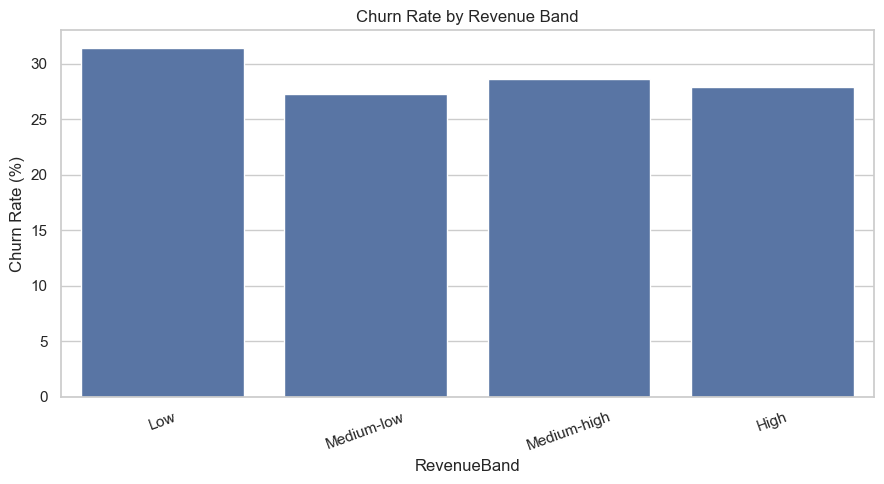

In [57]:
revenue_summary = create_churn_summary(df, "RevenueBand")
display(revenue_summary)
plt.figure(figsize=(9,5))
sns.barplot(data=revenue_summary, x="RevenueBand", y="ChurnRatePercent")
plt.title("Churn Rate by Revenue Band")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_DIR/"churn_by_revenue_band.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 28: Analyse Churn by Overage Usage

We calculate and visualise churn across overage usage groups.

**Why:** This helps identify customer segments with elevated churn and supports targeted retention decisions.

,OverageBand,CustomerCount,ChurnedCustomers,ChurnRate,AverageMonthlyRevenue,TotalMonthlyRevenue,ChurnRatePercent
0,None,23262,6603,0.28,42.97,999575.54,28.39
1,Low,6763,1833,0.27,43.02,290917.22,27.10
2,Moderate,9983,2853,0.29,53.46,533676.26,28.58
3,High,5059,1526,0.30,73.91,373889.82,30.16
4,Very high,5980,1896,0.32,134.39,803647.07,31.71


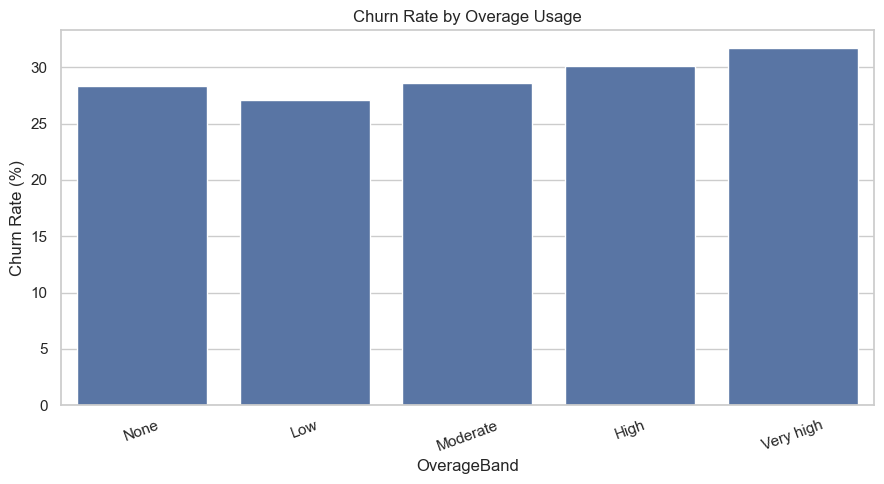

In [59]:
overage_summary = create_churn_summary(df, "OverageBand")
display(overage_summary)
plt.figure(figsize=(9,5))
sns.barplot(data=overage_summary, x="OverageBand", y="ChurnRatePercent")
plt.title("Churn Rate by Overage Usage")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_DIR/"churn_by_overage.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 29: Analyse Churn by Usage Trend

We calculate and visualise churn across usage trend groups.

**Why:** This helps identify customer segments with elevated churn and supports targeted retention decisions.

,UsageTrend,CustomerCount,ChurnedCustomers,ChurnRate,AverageMonthlyRevenue,TotalMonthlyRevenue,ChurnRatePercent
0,Large decline,16571,5167,0.31,68.69,1138221.80,31.18
1,Small decline,7590,2182,0.29,44.52,337928.35,28.75
2,Stable,6611,2112,0.32,37.69,249151.14,31.95
3,Small increase,6049,1528,0.25,46.72,282585.30,25.26
4,Large increase,14226,3722,0.26,69.86,993819.32,26.16


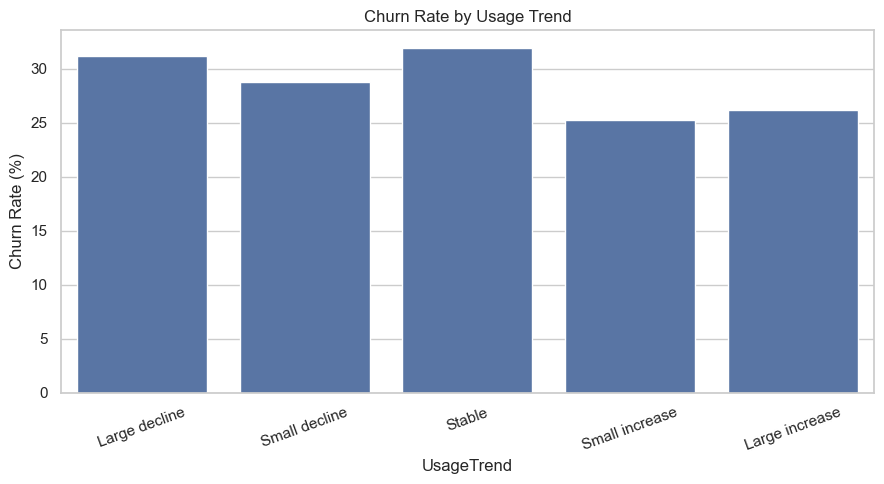

In [61]:
usage_summary = create_churn_summary(df, "UsageTrend")
display(usage_summary)
plt.figure(figsize=(9,5))
sns.barplot(data=usage_summary, x="UsageTrend", y="ChurnRatePercent")
plt.title("Churn Rate by Usage Trend")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_DIR/"churn_by_usage_trend.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 30: Analyse Churn by Customer Frustration

We calculate and visualise churn across customer frustration groups.

**Why:** This helps identify customer segments with elevated churn and supports targeted retention decisions.

,FrustrationQuartile,CustomerCount,ChurnedCustomers,ChurnRate,AverageMonthlyRevenue,TotalMonthlyRevenue,ChurnRatePercent
0,Q1 Low,12762,4027,0.32,37.51,478746.62,31.55
1,Q2 Medium-low,12762,3619,0.28,45.47,580225.30,28.36
2,Q3 Medium-high,12761,3577,0.28,60.41,770891.08,28.03
3,Q4 High,12762,3488,0.27,91.82,1171842.91,27.33


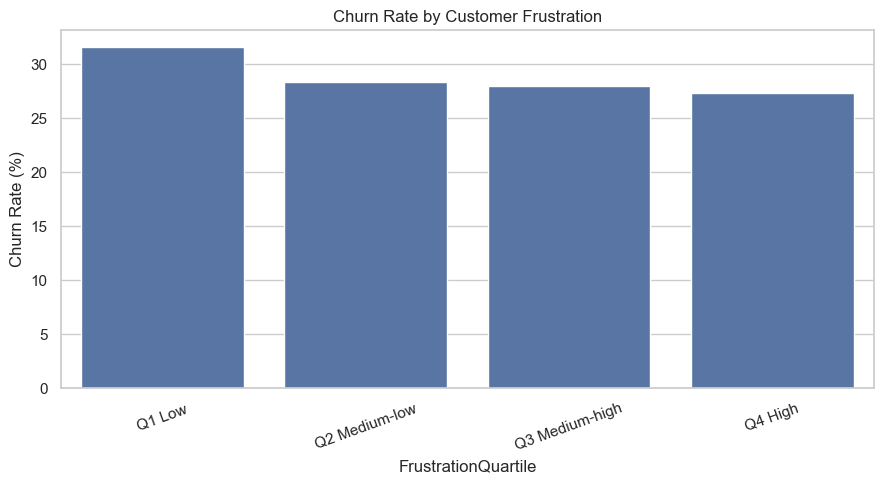

In [63]:
frustration_summary = create_churn_summary(df, "FrustrationQuartile")
display(frustration_summary)
plt.figure(figsize=(9,5))
sns.barplot(data=frustration_summary, x="FrustrationQuartile", y="ChurnRatePercent")
plt.title("Churn Rate by Customer Frustration")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_DIR/"churn_by_frustration.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 31: Cohort Analysis

We calculate churn for combinations of tenure and usage trend.

**Why:** Combining variables may reveal high-risk groups that are hidden when each factor is studied separately.

UsageTrend,Large decline,Small decline,Stable,Small increase,Large increase
TenureGroup,,,,,
0-12 months,29.29,27.57,28.53,21.59,24.30
13-24 months,33.59,29.47,34.16,26.94,28.31
25-48 months,29.70,28.87,32.36,27.00,25.30
49+ months,30.41,28.92,24.49,19.64,23.81


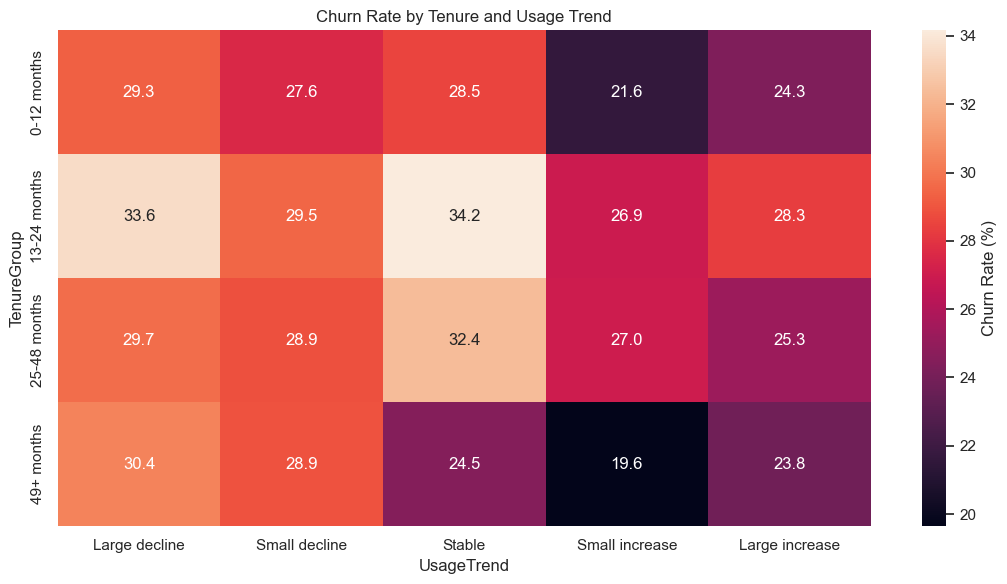

In [65]:
cohort_table = pd.pivot_table(
    df, values="Churn", index="TenureGroup", columns="UsageTrend",
    aggfunc="mean", observed=False
) * 100
display(cohort_table)
plt.figure(figsize=(11,6))
sns.heatmap(cohort_table, annot=True, fmt=".1f", cbar_kws={"label":"Churn Rate (%)"})
plt.title("Churn Rate by Tenure and Usage Trend")
plt.tight_layout()
plt.savefig(CHART_DIR/"cohort_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 32: Correlation Analysis

We calculate correlations between numeric variables and churn.

**Why:** Correlation identifies useful associations for exploration, although it does not prove causation.

,CorrelationWithChurn
CurrentEquipmentDays,0.10
MadeCallToRetentionTeam,0.07
RetentionCalls,0.07
HandsetWebCapable,-0.06
TotalRecurringCharge,-0.06
PercChangeMinutes_was_missing,0.05
PercChangeRevenues_was_missing,0.05
MonthlyMinutes,-0.05
CustomerID,-0.04
OffPeakCallsInOut,-0.04


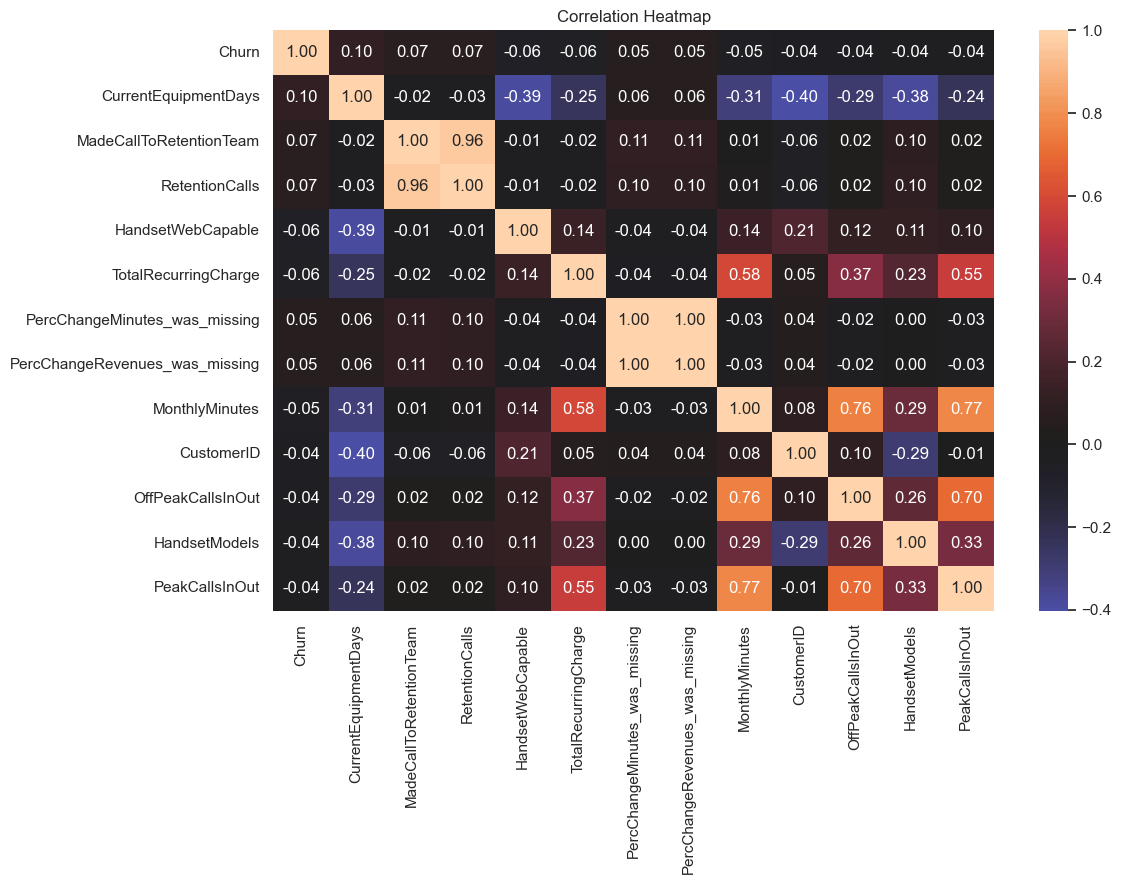

In [67]:
numeric_df = df.select_dtypes(include=np.number)
churn_correlations = (
    numeric_df.corr(numeric_only=True)["Churn"]
    .drop("Churn")
    .sort_values(key=lambda x:x.abs(), ascending=False)
)
display(churn_correlations.head(20).to_frame("CorrelationWithChurn"))
top = churn_correlations.head(12).index.tolist()
plt.figure(figsize=(12,9))
sns.heatmap(numeric_df[["Churn"]+top].corr(), annot=True, fmt=".2f", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(CHART_DIR/"correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 33: Create a Rule-Based Retention Risk Score

We assign points for short tenure, repeated care calls, declining usage, old equipment, high overage and high frustration.

**Why:** This produces an easy-to-explain operational priority score. It is a prioritisation tool, not a calibrated churn probability.

In [69]:
df["RiskScore"] = 0

df["RiskScore"] += np.where(
    df["CustomerCareCalls"] >= 4, 2,
    np.where(df["CustomerCareCalls"] >= 2, 1, 0)
)
df["RiskScore"] += np.where(
    df["MonthsInService"] <= 12, 2,
    np.where(df["MonthsInService"] <= 24, 1, 0)
)
df["RiskScore"] += np.where(
    df["PercChangeMinutes"] <= -50, 2,
    np.where(df["PercChangeMinutes"] <= -10, 1, 0)
)
df["RiskScore"] += np.where(df["CurrentEquipmentDays"] > 730, 1, 0)
df["RiskScore"] += np.where(df["OverageMinutes"] > 100, 1, 0)

# Add frustration points only to customers in the highest quartile.
# This avoids selecting too many customers when the raw score has tied values.
df["RiskScore"] += np.where(
    df["FrustrationQuartile"].astype(str) == "Q4 High",
    2,
    0
)

df["RetentionPriority"] = pd.cut(
    df["RiskScore"],
    bins=[-np.inf, 2, 5, np.inf],
    labels=["Low", "Medium", "High"]
)

display(
    df[["RiskScore", "RetentionPriority"]]
    .value_counts()
    .reset_index(name="CustomerCount")
)


,RiskScore,RetentionPriority,CustomerCount
0,2,Low,11689
1,1,Low,10793
2,3,Medium,9121
3,4,Medium,6644
4,5,Medium,3891
5,6,High,3349
6,0,Low,2329
7,7,High,1764
8,8,High,1137
9,9,High,330


## Step 34: Build the Retention Action List

We filter active customers and rank them by risk and revenue.

**Why:** This converts historical analysis into an operational list showing who should be contacted first.

In [71]:
id_candidates = ["CustomerID","CustomerId","customer_id","Customer"]
customer_id_column = next((c for c in id_candidates if c in df.columns), None)
retention_columns = [c for c in [
    customer_id_column,"Churn","RiskScore","RetentionPriority","MonthlyRevenue",
    "MonthsInService","TenureGroup","CustomerCareCalls","CareCallGroup",
    "PercChangeMinutes","UsageTrend","CurrentEquipmentDays","DeviceAgeGroup",
    "OverageMinutes","OverageBand","FrustrationScore","FrustrationQuartile"
] if c is not None and c in df.columns]

retention_action_list = (
    df.loc[df["Churn"]==0, retention_columns]
    .sort_values(["RiskScore","MonthlyRevenue"], ascending=[False,False])
    .reset_index(drop=True)
)
display(retention_action_list.head(25))

retention_priority_summary = (
    retention_action_list.groupby("RetentionPriority", observed=False)
    .agg(
        ActiveCustomers=("Churn","size"),
        AverageRiskScore=("RiskScore","mean"),
        AverageMonthlyRevenue=("MonthlyRevenue","mean"),
        TotalMonthlyRevenue=("MonthlyRevenue","sum")
    ).reset_index()
)
display(retention_priority_summary)

,CustomerID,Churn,RiskScore,RetentionPriority,MonthlyRevenue,MonthsInService,TenureGroup,CustomerCareCalls,CareCallGroup,PercChangeMinutes,UsageTrend,CurrentEquipmentDays,DeviceAgeGroup,OverageMinutes,OverageBand,FrustrationScore,FrustrationQuartile
0,3206798,0,9,High,626.36,12,0-12 months,5.70,4-6 calls,-2858.00,Large decline,183.00,6-12 months,1718.00,Very high,12.33,Q4 High
1,3279706,0,9,High,478.94,11,0-12 months,15.30,7+ calls,-2051.00,Large decline,78.00,Under 6 months,980.00,Very high,4.00,Q4 High
2,3241938,0,9,High,463.32,10,0-12 months,17.30,7+ calls,-537.00,Large decline,318.00,6-12 months,1190.00,Very high,19.92,Q4 High
3,3337114,0,9,High,434.33,7,0-12 months,5.30,4-6 calls,-320.00,Large decline,198.00,6-12 months,1150.00,Very high,6.38,Q4 High
4,3373302,0,9,High,367.68,6,0-12 months,28.00,7+ calls,-791.00,Large decline,149.00,Under 6 months,898.00,Very high,19.35,Q4 High
5,3358122,0,9,High,352.60,9,0-12 months,22.30,7+ calls,-135.00,Large decline,29.00,Under 6 months,739.00,Very high,12.07,Q4 High
6,3358742,0,9,High,338.06,9,0-12 months,63.70,7+ calls,-280.00,Large decline,115.00,Under 6 months,519.00,Very high,14.65,Q4 High
7,3337682,0,9,High,317.46,7,0-12 months,5.30,4-6 calls,-917.00,Large decline,197.00,6-12 months,885.00,Very high,5.28,Q4 High
8,3282718,0,9,High,315.28,8,0-12 months,4.30,4-6 calls,-170.00,Large decline,244.00,6-12 months,623.00,Very high,6.61,Q4 High
9,3287286,0,9,High,288.63,8,0-12 months,30.00,7+ calls,-1400.00,Large decline,130.00,Under 6 months,307.00,Very high,8.63,Q4 High


,RetentionPriority,ActiveCustomers,AverageRiskScore,AverageMonthlyRevenue,TotalMonthlyRevenue
0,Low,17796,1.38,44.99,800644.66
1,Medium,13769,3.75,64.73,891330.81
2,High,4771,6.77,95.84,457232.85


## Step 35: SQL Analysis with DuckDB

We register the cleaned DataFrame as a DuckDB table and run SQL queries.

**Why:** SQL is a core Data Analyst skill. DuckDB allows SQL analysis directly inside Jupyter without a separate database server.

In [73]:
con = duckdb.connect()
con.register("cell2cell", df)

sql_executive_summary = con.execute('''
SELECT
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned_customers,
    ROUND(AVG(Churn)*100,2) AS churn_rate_percent,
    ROUND(SUM(MonthlyRevenue),2) AS total_monthly_revenue,
    ROUND(SUM(CASE WHEN Churn=1 THEN MonthlyRevenue ELSE 0 END),2)
        AS monthly_revenue_associated_with_churn
FROM cell2cell
''').df()
display(sql_executive_summary)

sql_churn_by_tenure = con.execute('''
SELECT
    TenureGroup,
    COUNT(*) AS customer_count,
    SUM(Churn) AS churned_customers,
    ROUND(AVG(Churn)*100,2) AS churn_rate_percent,
    ROUND(AVG(MonthlyRevenue),2) AS average_monthly_revenue
FROM cell2cell
GROUP BY TenureGroup
ORDER BY churn_rate_percent DESC
''').df()
display(sql_churn_by_tenure)

sql_ranked_customers = con.execute('''
SELECT *,
    RANK() OVER (ORDER BY RiskScore DESC, MonthlyRevenue DESC) AS retention_rank,
    NTILE(10) OVER (ORDER BY RiskScore DESC, MonthlyRevenue DESC) AS risk_decile
FROM cell2cell
WHERE Churn=0
ORDER BY retention_rank
''').df()
display(sql_ranked_customers.head(25))

,total_customers,churned_customers,churn_rate_percent,total_monthly_revenue,monthly_revenue_associated_with_churn
0,51047,14711.00,28.82,3001705.91,852497.59


,TenureGroup,customer_count,churned_customers,churn_rate_percent,average_monthly_revenue
0,13-24 months,21422,6591.00,30.77,58.45
1,25-48 months,12067,3447.00,28.57,57.91
2,0-12 months,16975,4520.00,26.63,59.61
3,49+ months,583,153.00,26.24,66.80


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus,AgeHH2_was_missing,PercChangeMinutes_was_missing,PercChangeRevenues_was_missing,TenureGroup,UsageTrend,CareCallGroup,DeviceAgeGroup,RevenueBand,OverageBand,EstimatedLifetimeRevenue,FrustrationScore,FrustrationQuartile,RiskScore,RetentionPriority,retention_rank,risk_decile
0,3206798,0,626.36,2858.00,22.00,7.92,1718.00,0.00,-2858.00,-626.40,54.30,9.00,86.30,5.70,0.30,926.00,50.70,2.00,328.00,358.70,63.30,0.00,45.70,12,1,1,BOSWOR508,2.00,2.00,183.00,0.00,0.00,0,0,1,0,0,Unknown,0,0,0,0,0,0,0,0,1,0,0,0,0,0,60,0,7-Lowest,Suburban,Other,Unknown,0,0,0,0-12 months,Large decline,4-6 calls,6-12 months,High,Very high,7516.32,12.33,Q4 High,9,High,1,1
1,3279706,0,478.94,2110.00,43.00,1.24,980.00,17.50,-2051.00,-436.50,13.70,5.30,37.70,15.30,0.30,477.70,83.70,12.00,179.00,101.70,19.00,0.00,8.70,11,1,1,KCYKCK913,2.00,2.00,78.00,0.00,0.00,0,0,1,0,0,Unknown,0,0,0,0,0,0,0,0,0,1,0,0,0,0,200,0,5-Low,Suburban,Other,Unknown,0,0,0,0-12 months,Large decline,7+ calls,Under 6 months,High,Very high,5268.34,4.00,Q4 High,9,High,2,1
2,3241938,0,463.32,3237.00,110.00,0.25,1190.00,19.30,-537.00,-194.80,49.70,22.30,267.70,17.30,15.70,827.00,74.30,13.00,811.30,498.70,72.00,0.00,38.70,10,1,1,PHXSCO480,1.00,1.00,318.00,44.00,44.00,0,0,1,1,1,Unknown,0,0,0,0,0,1,0,0,0,0,0,5,0,0,Unknown,0,5-Low,Town,Other,No,0,0,0,0-12 months,Large decline,7+ calls,6-12 months,High,Very high,4633.20,19.92,Q4 High,9,High,3,1
3,3337114,0,434.33,2650.00,45.00,0.00,1150.00,0.00,-320.00,-108.80,12.70,1.70,110.00,5.30,0.00,858.20,29.00,2.00,108.00,273.00,14.30,0.00,16.00,7,1,1,LAXVIC760,1.00,1.00,198.00,0.00,0.00,0,0,1,0,0,Unknown,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Unknown,0,3-Good,Other,Other,Unknown,0,0,0,0-12 months,Large decline,4-6 calls,6-12 months,High,Very high,3040.31,6.38,Q4 High,9,High,4,1
4,3373302,0,367.68,5080.00,167.00,4.95,898.00,2.90,-791.00,-184.40,55.30,39.30,194.30,28.00,1.70,2138.50,344.00,133.70,636.70,479.00,108.30,0.30,44.70,6,1,1,SANAUS512,2.00,2.00,149.00,36.00,44.00,0,1,1,0,0,Unknown,0,0,0,0,0,0,0,0,0,0,0,0,0,0,150,0,5-Low,Suburban,Other,Unknown,1,0,0,0-12 months,Large decline,7+ calls,Under 6 months,High,Very high,2206.08,19.35,Q4 High,9,High,5,1
5,3358122,0,352.60,2193.00,56.00,0.99,739.00,0.00,-135.00,-45.00,26.30,3.00,200.00,22.30,2.00,450.10,84.00,93.00,364.30,377.70,29.30,0.00,9.70,9,1,1,BOSWOR508,4.00,3.00,29.00,20.00,0.00,0,0,1,0,0,Known,0,0,0,0,0,1,0,0,0,0,0,7,0,0,200,0,4-Medium,Suburban,Other,Unknown,0,0,0,0-12 months,Large decline,7+ calls,Under 6 months,High,Very high,3173.40,12.07,Q4 High,9,High,6,1
6,3358742,0,338.06,2077.00,48.00,7.67,519.00,0.40,-280.00,165.10,44.00,30.30,137.70,63.70,5.30,545.30,122.30,82.30,397.30,279.00,76.70,0.00,15.30,9,1,1,DENDEN303,2.00,2.00,115.00,46.00,0.00,0,0,1,0,0,Known,0,0,0,0,0,1,0,0,0,0,0,4,0,0,100,0,5-Low,Suburban,Other,No,0,0,0,0-12 months,Large decline,7+ calls,Under 6 months,High,Very high,3042.54,14.65,Q4 High,9,High,7,1
7,3337682,0,317.46,1374.00,50.00,0.00,885.00,0.00,-917.00,-267.50,2.30,54.00,6.30,5.30,1.30,342.50,59.00,12.00,100.00,68.00,56.30,0.00,3.00,7,2,2,NCRRIC804,1.00,1.00,197.00,52.00,0.00,0,0,0,0,0,Known,0,0,0,0,0,1,0,0,0,0,0,5,0,0,Unkno

## Step 36: Prepare Data for Machine Learning

We separate the target from the predictor variables, remove identifiers, exclude rule-based dashboard fields, and remove variables that could introduce data leakage.

Why: All five models must be trained on the same clean feature set. The target must not appear among the inputs, identifiers provide little predictive value, and post-retention or derived risk fields could unfairly reveal churn information..

In [75]:
target_column = "Churn"

columns_to_exclude = [
    "CustomerID",
    "Churn",
    "Customer Status",

    # Rule-based dashboard fields
    "RiskScore",
    "RetentionPriority",
    "FrustrationScore",
    "FrustrationQuartile",

    # Grouped analytical fields
    "RevenueBand",
    "TenureGroup",
    "UsageTrend",
    "CareCallGroup",
    "DeviceAgeGroup",
    "OverageBand",

    # Potential post-intervention leakage
    "RetentionCalls",
    "RetentionOffersAccepted",
    "MadeCallToRetentionTeam"
]

columns_to_exclude = [
    col for col in columns_to_exclude
    if col in df.columns
]

X = df.drop(columns=columns_to_exclude).copy()
y = df[target_column].astype(int).copy()

print("Model rows:", X.shape[0])
print("Features before encoding:", X.shape[1])

display(
    y.value_counts()
    .rename_axis("Churn")
    .reset_index(name="CustomerCount")
)

Model rows: 51047
Features before encoding: 57


,Churn,CustomerCount
0,0,36336
1,1,14711


## Step 37: Identify Numeric and Categorical Features

In [77]:
numeric_features = X.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=["number", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 50
Categorical features: 7


## Step 38: Split Training and Test Data

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training churn rate:", f"{y_train.mean():.2%}")
print("Testing churn rate:", f"{y_test.mean():.2%}")

Training rows: 40837
Testing rows: 10210
Training churn rate: 28.82%
Testing churn rate: 28.81%


## Step 39: Build the Preprocessing Pipeline

In [81]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

## Step 40: Define the Five Machine-Learning Models

### What are we doing?

We define five classification algorithms:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbours
5. XGBoost

Each model will use the same training data and preprocessing pipeline.

### Why are we doing it?

Different algorithms identify patterns in different ways. Comparing several models helps us determine which approach produces the strongest and most useful churn predictions.

- Logistic Regression provides an interpretable baseline.
- Decision Tree creates simple decision rules.
- Random Forest combines many trees for more stable predictions.
- KNN classifies customers based on similar customer profiles.
- XGBoost builds trees sequentially and focuses on correcting previous errors.

Because churned customers are less common than retained customers, class-balancing options are used where the algorithm supports them.

#### calculate class imbalance

In [84]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

if positive_count == 0:
    raise ValueError(
        "The training data contains no churned customers."
    )

scale_pos_weight = negative_count / positive_count

print("Training class distribution")
print("---------------------------")
print(f"Retained customers: {negative_count:,}")
print(f"Churned customers:  {positive_count:,}")
print(f"XGBoost scale_pos_weight: {scale_pos_weight:.3f}")

Training class distribution
---------------------------
Retained customers: 29,068
Churned customers:  11,769
XGBoost scale_pos_weight: 2.470


scale_pos_weight is the ratio of retained customers to churned customers. XGBoost uses this value to give more importance to the smaller churn class.

#### define the models

In [87]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "K-Nearest Neighbours": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        metric="minkowski",
        p=2,
        algorithm="brute",
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=1.00,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

print("Models prepared:")
for model_name in models:
    print(f"- {model_name}")

Models prepared:
- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbours
- XGBoost


## Step 41: Train and Evaluate All Five Models

### What are we doing?

We create one pipeline for each model. Each pipeline:

1. Applies the same preprocessing steps
2. Trains the selected algorithm
3. Predicts churn classes
4. Produces churn probabilities
5. Calculates evaluation metrics

The calculated metrics are:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC

### Why are we doing it?

Using one common evaluation process ensures that all models are compared fairly.

Accuracy alone is not sufficient because the classes are imbalanced. Recall, precision, F1, ROC-AUC and PR-AUC provide a more complete view of how well each model identifies churned customers.

In [89]:
model_results = []
trained_pipelines = {}
model_predictions = {}
failed_models = {}

for model_name, model in models.items():
    print("=" * 75)
    print(f"Training: {model_name}")
    print("=" * 75)

    try:
        model_pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model)
            ]
        )

        # Train the model
        model_pipeline.fit(X_train, y_train)

        # KNN needs batched prediction to avoid a large distance matrix
        if model_name == "K-Nearest Neighbours":
            batch_size = 250

            predicted_classes = []
            predicted_probabilities = []

            for start in range(0, len(X_test), batch_size):
                end = min(start + batch_size, len(X_test))

                X_test_batch = X_test.iloc[start:end]

                batch_pred = model_pipeline.predict(
                    X_test_batch
                )

                batch_probability = (
                    model_pipeline
                    .predict_proba(X_test_batch)[:, 1]
                )

                predicted_classes.append(batch_pred)
                predicted_probabilities.append(
                    batch_probability
                )

                print(
                    f"KNN prediction progress: "
                    f"{end:,}/{len(X_test):,}"
                )

            y_pred = np.concatenate(
                predicted_classes
            )

            y_probability = np.concatenate(
                predicted_probabilities
            )

        else:
            y_pred = model_pipeline.predict(X_test)

            y_probability = (
                model_pipeline
                .predict_proba(X_test)[:, 1]
            )

        # Calculate metrics
        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            y_test,
            y_probability
        )

        pr_auc = average_precision_score(
            y_test,
            y_probability
        )

        # Store model results
        model_results.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc
        })

        trained_pipelines[model_name] = (
            model_pipeline
        )

        model_predictions[model_name] = {
            "PredictedClass": y_pred,
            "PredictedProbability": y_probability
        }

        print(
            classification_report(
                y_test,
                y_pred,
                target_names=[
                    "Retained",
                    "Churned"
                ],
                zero_division=0
            )
        )

    except Exception as error:
        failed_models[model_name] = str(error)

        print(
            f"{model_name} failed:"
        )
        print(error)

        print(
            "\nContinuing with the remaining models.\n"
        )

print("=" * 75)
print("TRAINING SUMMARY")
print("=" * 75)

print(
    "Successfully trained:",
    list(trained_pipelines.keys())
)

if failed_models:
    print("\nFailed models:")

    for model_name, error_message in (
        failed_models.items()
    ):
        print(
            f"- {model_name}: "
            f"{error_message}"
        )
else:
    print(
        "\nAll five models were trained successfully."
    )

Training: Logistic Regression
              precision    recall  f1-score   support

    Retained       0.77      0.58      0.66      7268
     Churned       0.35      0.57      0.44      2942

    accuracy                           0.58     10210
   macro avg       0.56      0.58      0.55     10210
weighted avg       0.65      0.58      0.60     10210

Training: Decision Tree
              precision    recall  f1-score   support

    Retained       0.79      0.56      0.65      7268
     Churned       0.36      0.63      0.46      2942

    accuracy                           0.58     10210
   macro avg       0.58      0.59      0.56     10210
weighted avg       0.67      0.58      0.60     10210

Training: Random Forest
              precision    recall  f1-score   support

    Retained       0.79      0.63      0.70      7268
     Churned       0.39      0.58      0.47      2942

    accuracy                           0.62     10210
   macro avg       0.59      0.61      0.58     10

## Step 42: Compare Model Performance

### What are we doing?

We combine all model results into one comparison table and visualise the main evaluation metrics.

### Why are we doing it?

The comparison helps us identify which model provides the strongest overall churn predictions. It also shows the trade-off between identifying more churners and avoiding false churn alerts.

#### comparison table

In [92]:
results_df = pd.DataFrame(model_results)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

results_df[metric_columns] = (
    results_df[metric_columns]
    .astype(float)
)

results_df = (
    results_df
    .sort_values(
        by="ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    results_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "PR-AUC": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.628,0.406,0.632,0.495,0.677,0.457
1,Random Forest,0.618,0.390,0.577,0.466,0.652,0.420
2,Decision Tree,0.578,0.365,0.628,0.462,0.629,0.392
3,Logistic Regression,0.576,0.355,0.575,0.439,0.608,0.372
4,K-Nearest Neighbours,0.700,0.397,0.076,0.127,0.557,0.335


#### comparision chart

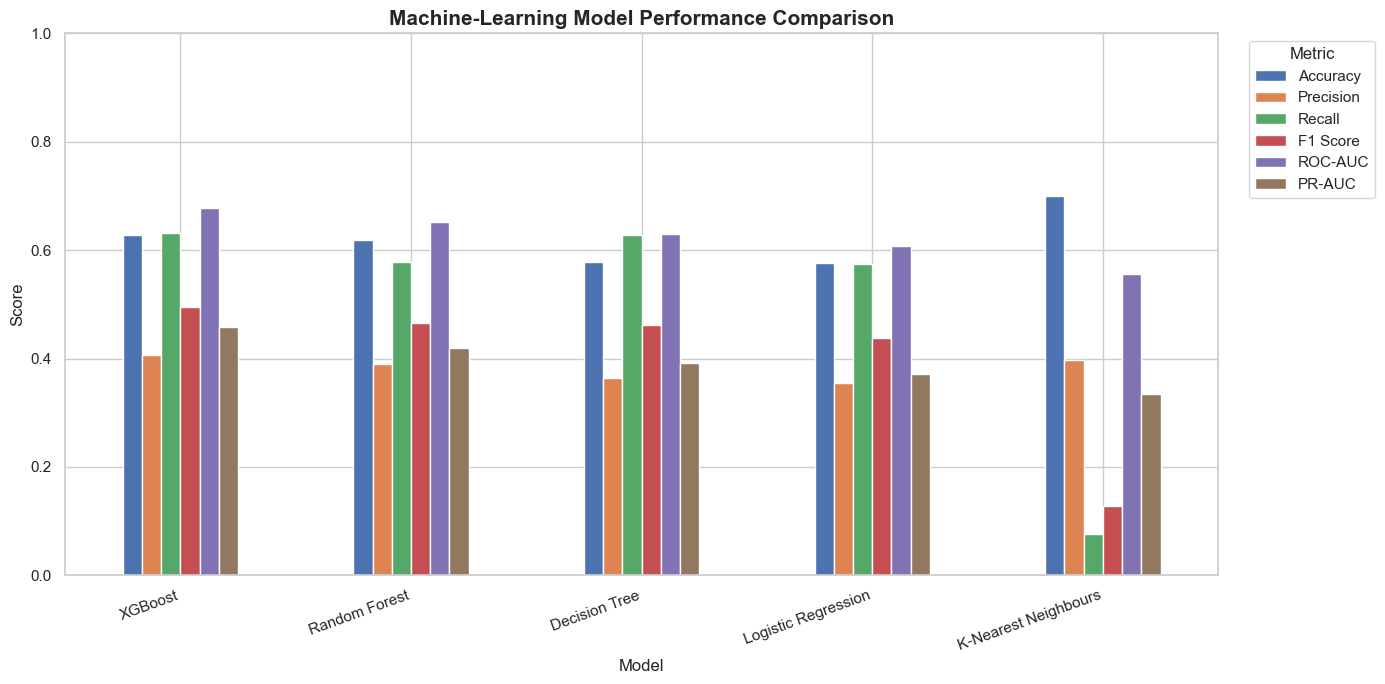

Comparison chart saved to: C:\Users\suhan\Project\Customer Churn Prediction\outputs\charts\model_performance_comparison.png


In [94]:
comparison_plot = (
    results_df
    .set_index("Model")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC",
            "PR-AUC"
        ]
    ]
)

ax = comparison_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

ax.set_title(
    "Machine-Learning Model Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

comparison_chart_path = (
    CHART_DIR / "model_performance_comparison.png"
)

plt.savefig(
    comparison_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Comparison chart saved to: {comparison_chart_path}")

#### long-format results for Power BI

In [96]:
model_results_long = results_df.melt(
    id_vars="Model",
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Score"
)

display(model_results_long.head(10))

,Model,Metric,Score
0,XGBoost,Accuracy,0.63
1,Random Forest,Accuracy,0.62
2,Decision Tree,Accuracy,0.58
3,Logistic Regression,Accuracy,0.58
4,K-Nearest Neighbours,Accuracy,0.70
5,XGBoost,Precision,0.41
6,Random Forest,Precision,0.39
7,Decision Tree,Precision,0.36
8,Logistic Regression,Precision,0.35
9,K-Nearest Neighbours,Precision,0.40


## Step 43: Display Confusion Matrices

### What are we doing?

We create a confusion matrix for each model.

Each matrix shows:

- True negatives: retained customers correctly classified
- False positives: retained customers incorrectly flagged as churners
- False negatives: churners the model failed to identify
- True positives: churners correctly identified

### Why are we doing it?

Two models can have similar accuracy but make very different types of mistakes. For retention analysis, false negatives are especially important because they represent customers who churned without being identified.

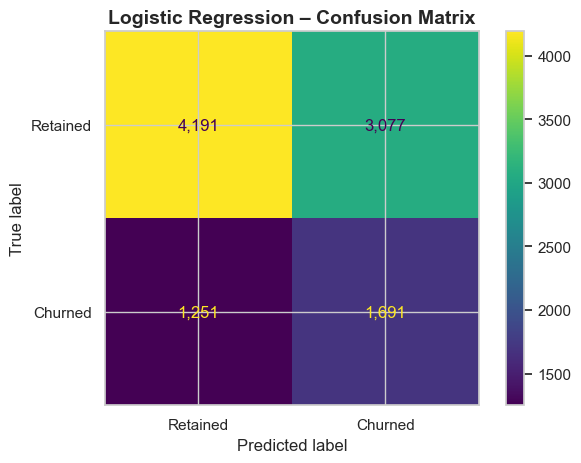

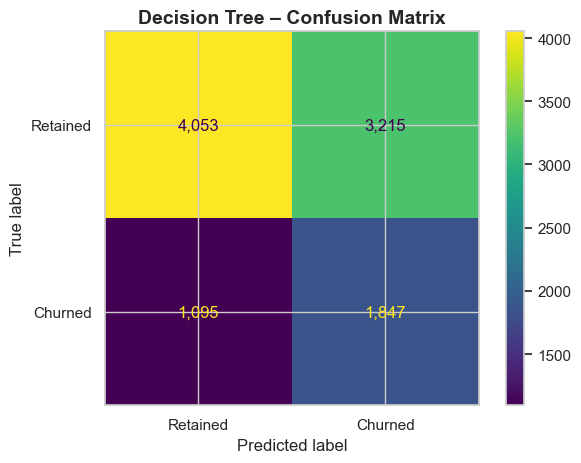

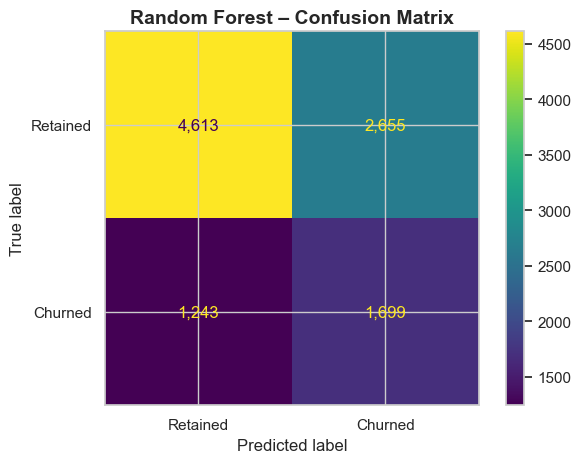

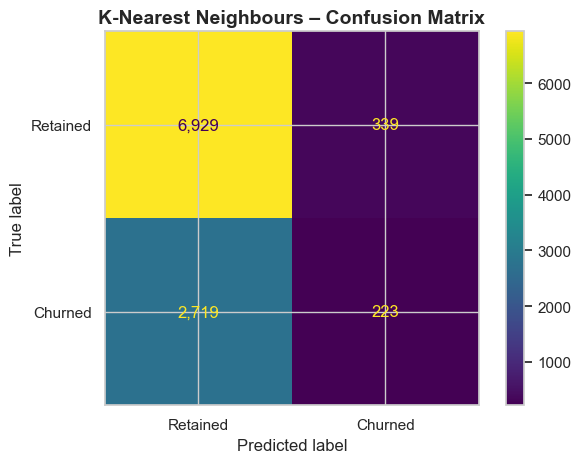

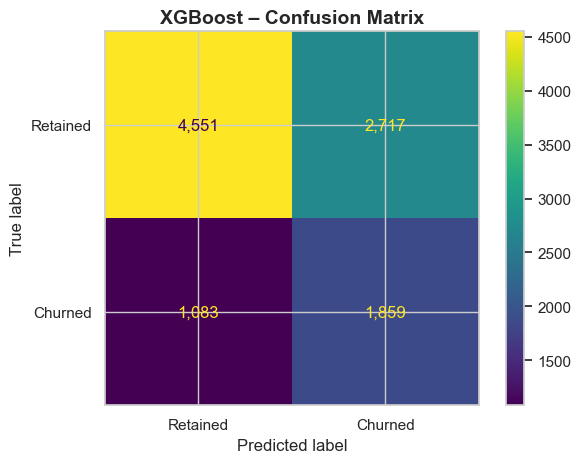

In [98]:
for model_name in models.keys():
    y_pred = model_predictions[model_name]["PredictedClass"]

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Retained", "Churned"],
        values_format=","
    )

    plt.title(
        f"{model_name} – Confusion Matrix",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    safe_model_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "")
    )

    confusion_matrix_path = (
        CHART_DIR /
        f"{safe_model_name}_confusion_matrix.png"
    )

    plt.savefig(
        confusion_matrix_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## Step 44: Compare ROC and Precision-Recall Curves

### What are we doing?

We plot all five models on:

1. A Receiver Operating Characteristic curve
2. A Precision-Recall curve

### Why are we doing it?

The ROC curve measures how effectively each model separates churners from retained customers across different thresholds.

The Precision-Recall curve is particularly useful because churn is the minority class. It shows the trade-off between finding more churners and keeping churn predictions accurate.

#### ROC curves

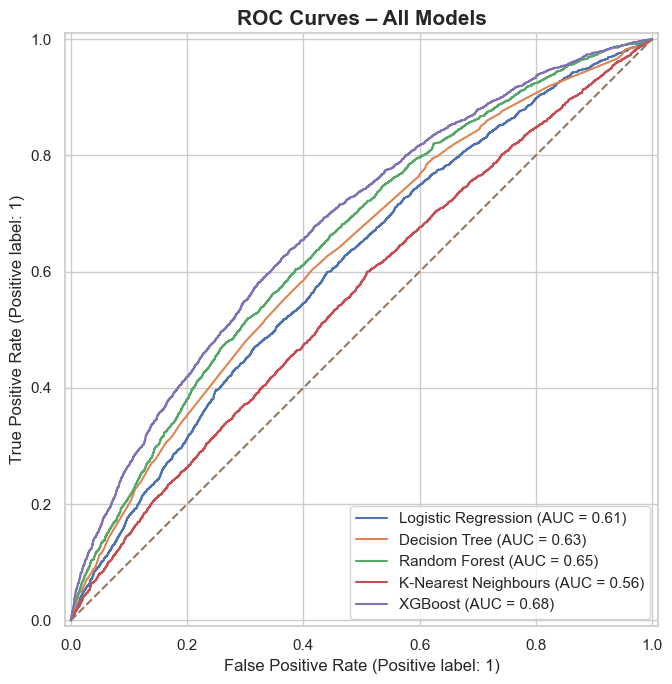

ROC chart saved to: C:\Users\suhan\Project\Customer Churn Prediction\outputs\charts\all_models_roc_curves.png


In [101]:
fig, ax = plt.subplots(figsize=(10, 7))

for model_name in models.keys():
    y_probability = (
        model_predictions[model_name]
        ["PredictedProbability"]
    )

    RocCurveDisplay.from_predictions(
        y_test,
        y_probability,
        name=model_name,
        ax=ax
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

ax.set_title(
    "ROC Curves – All Models",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

roc_chart_path = (
    CHART_DIR / "all_models_roc_curves.png"
)

plt.savefig(
    roc_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"ROC chart saved to: {roc_chart_path}")

#### Precision-Recall curves

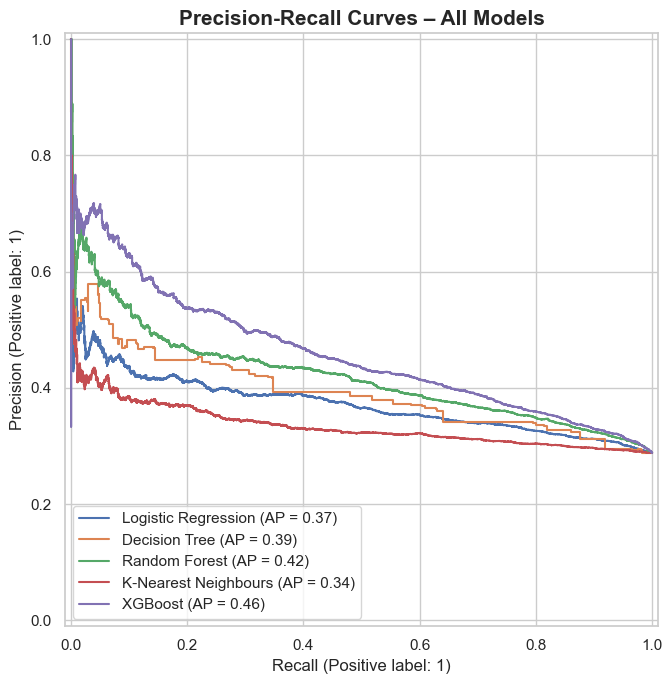

Precision-recall chart saved to: C:\Users\suhan\Project\Customer Churn Prediction\outputs\charts\all_models_precision_recall_curves.png


In [103]:
fig, ax = plt.subplots(figsize=(10, 7))

for model_name in models.keys():
    y_probability = (
        model_predictions[model_name]
        ["PredictedProbability"]
    )

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_probability,
        name=model_name,
        ax=ax
    )

ax.set_title(
    "Precision-Recall Curves – All Models",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

pr_chart_path = (
    CHART_DIR /
    "all_models_precision_recall_curves.png"
)

plt.savefig(
    pr_chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Precision-recall chart saved to: {pr_chart_path}")

## Step 45: Select the Best Model

### What are we doing?

We rank the models primarily by ROC-AUC and identify the top-performing model.

### Why are we doing it?

The business needs one model for operational churn scoring. ROC-AUC is used as the main ranking metric because it measures the model's overall ability to distinguish churners from retained customers.

However, the final choice should also consider recall, precision, F1 Score and business costs. A model with slightly lower ROC-AUC may still be preferred if it identifies substantially more churners.

In [105]:
best_model_row = results_df.iloc[0]

best_model_name = best_model_row["Model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model based on ROC-AUC")
print("---------------------------")
print(f"Model:     {best_model_name}")
print(f"Accuracy:  {best_model_row['Accuracy']:.3f}")
print(f"Precision: {best_model_row['Precision']:.3f}")
print(f"Recall:    {best_model_row['Recall']:.3f}")
print(f"F1 Score:  {best_model_row['F1 Score']:.3f}")
print(f"ROC-AUC:   {best_model_row['ROC-AUC']:.3f}")
print(f"PR-AUC:    {best_model_row['PR-AUC']:.3f}")

Best model based on ROC-AUC
---------------------------
Model:     XGBoost
Accuracy:  0.628
Precision: 0.406
Recall:    0.632
F1 Score:  0.495
ROC-AUC:   0.677
PR-AUC:    0.457


In [106]:
metric_winners = pd.DataFrame({
    "Metric": metric_columns,
    "BestModel": [
        results_df.loc[
            results_df[metric].idxmax(),
            "Model"
        ]
        for metric in metric_columns
    ],
    "BestScore": [
        results_df[metric].max()
        for metric in metric_columns
    ]
})

display(
    metric_winners.style.format({
        "BestScore": "{:.3f}"
    })
)

,Metric,BestModel,BestScore
0,Accuracy,K-Nearest Neighbours,0.700
1,Precision,XGBoost,0.406
2,Recall,XGBoost,0.632
3,F1 Score,XGBoost,0.495
4,ROC-AUC,XGBoost,0.677
5,PR-AUC,XGBoost,0.457


### Model-selection conclusion

KNN correctly classifies the highest percentage of all customers, but accuracy can be misleading because approximately 71% of customers are retained. A model can achieve relatively high accuracy by predicting more customers as retained.

XGBoost performs best on the metrics that matter more for churn prediction:

It identifies 63.2% of actual churners.
It has the best balance between precision and recall.
It has the strongest ability to rank churners above retained customers.
It performs best on the minority churn class according to PR-AUC.

## Step 46: Save the Best Model

### What are we doing?

We save the complete best-performing pipeline, including preprocessing and the trained model.

### Why are we doing it?

Saving the full pipeline allows the same transformations and model to be applied to future customer data without retraining the model or manually repeating preprocessing.

In [109]:
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

best_model_filename = (
    best_model_name.lower()
    .replace(" ", "_")
    .replace("-", "")
)

best_model_path = (
    MODEL_DIR /
    f"best_churn_model_{best_model_filename}.joblib"
)

joblib.dump(
    best_pipeline,
    best_model_path
)

print("Best model saved successfully.")
print(f"Model: {best_model_name}")
print(f"Path: {best_model_path.resolve()}")

Best model saved successfully.
Model: XGBoost
Path: C:\Users\suhan\Project\Customer Churn Prediction\models\best_churn_model_xgboost.joblib


#### Optional verification cell

In [111]:
loaded_best_model = joblib.load(
    best_model_path
)

verification_predictions = (
    loaded_best_model.predict(
        X_test.head(5)
    )
)

print(
    "Verification predictions:",
    verification_predictions
)

Verification predictions: [0 1 1 1 1]


## Step 48: Export XGBoost Feature Importance for Power BIg?

We extract feature importance scores from the trained XGBoost model and export them as a CSV file.

### Why are we doing it?

Feature importance helps identify which variables contributed most to the model's churn predictions. The exported file will be used in Power BI to create the **Top Drivers of Churn** visual.

Feature importance represents predictive contribution within the model and should not be interpreted as proof that a feature causes churn.

In [113]:
# Retrieve the trained XGBoost pipeline
xgb_pipeline = trained_pipelines["XGBoost"]

# Get the fitted preprocessor and XGBoost model
fitted_preprocessor = xgb_pipeline.named_steps["preprocessor"]
fitted_xgb = xgb_pipeline.named_steps["model"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get XGBoost feature importance scores
importance_scores = fitted_xgb.feature_importances_

# Create feature importance table
xgb_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_scores
})

# Sort from most important to least important
xgb_feature_importance = (
    xgb_feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(xgb_feature_importance.head(20))

,Feature,Importance
0,categorical__HandsetPrice_Unknown,0.02
1,numeric__CurrentEquipmentDays,0.02
2,numeric__HandsetRefurbished,0.01
3,numeric__MonthsInService,0.01
4,categorical__CreditRating_5-Low,0.01
5,numeric__PercChangeMinutes_was_missing,0.01
6,numeric__HandsetWebCapable,0.01
7,numeric__PercChangeRevenues_was_missing,0.01
8,numeric__MonthlyMinutes,0.01
9,numeric__PercChangeMinutes,0.01


Right now XGBoost is giving importance to the post-preprocessing features. For example:

categorical__HandsetPrice_Unknown
numeric__CurrentEquipmentDays
categorical__CreditRating_5-Low
categorical__ServiceArea_ATLATL678

Those are technically valid model features, but they are not stakeholder-friendly business drivers.

More importantly, categorical variables have been split by one-hot encoding. So CreditRating, ServiceArea, HandsetPrice, etc. can each be represented by many individual columns. Looking only at individual encoded features can therefore understate the importance of the original variable.

##### Create two XGBoost feature-importance tables:

Detailed importance — preserve exactly what XGBoost produced for technical/model documentation.

Grouped importance — combine encoded features back into their original variables. Use this one in Power BI

In [116]:
# ============================================================
# GROUP XGBOOST FEATURE IMPORTANCE BY ORIGINAL BUSINESS FEATURE
# ============================================================

xgb_pipeline = trained_pipelines["XGBoost"]

fitted_preprocessor = xgb_pipeline.named_steps["preprocessor"]
fitted_xgb = xgb_pipeline.named_steps["model"]

# Get transformed feature names
transformed_features = fitted_preprocessor.get_feature_names_out()

# Get XGBoost importance
importance_values = fitted_xgb.feature_importances_

# Detailed table
xgb_feature_importance = pd.DataFrame({
    "Feature": transformed_features,
    "Importance": importance_values
})

# ------------------------------------------------------------
# Identify the original numerical and categorical columns
# ------------------------------------------------------------

numeric_columns = list(
    fitted_preprocessor.transformers_[0][2]
)

categorical_columns = list(
    fitted_preprocessor.transformers_[1][2]
)

def get_original_feature(transformed_name):

    # Remove ColumnTransformer prefix
    clean_name = (
        transformed_name
        .replace("numeric__", "")
        .replace("categorical__", "")
    )

    # Exact numerical feature
    if clean_name in numeric_columns:
        return clean_name

    # Missing-indicator columns created from numerical variables
    if clean_name.endswith("_was_missing"):
        original = clean_name.replace("_was_missing", "")
        if original in numeric_columns:
            return original

    # One-hot encoded categorical variables
    # Find the original column whose name appears at the start
    for column in categorical_columns:
        if clean_name == column or clean_name.startswith(column + "_"):
            return column

    # Fallback
    return clean_name


xgb_feature_importance["OriginalFeature"] = (
    xgb_feature_importance["Feature"]
    .apply(get_original_feature)
)

# Aggregate importance scores
xgb_grouped_importance = (
    xgb_feature_importance
    .groupby("OriginalFeature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(
    xgb_grouped_importance.head(20)
)

,OriginalFeature,Importance
0,ServiceArea,0.55
1,HandsetPrice,0.07
2,CreditRating,0.04
3,Occupation,0.03
4,PrizmCode,0.02
5,CurrentEquipmentDays,0.02
6,HandsetRefurbished,0.01
7,MonthsInService,0.01
8,MaritalStatus,0.01
9,PercChangeMinutes_was_missing,0.01


In [117]:
# Create stakeholder-friendly feature importance table for Power BI

xgb_powerbi_importance = (
    xgb_grouped_importance.copy()
)

# Remove technical / non-actionable fields from the dashboard version
exclude_from_dashboard = [
    "ServiceArea",
    "PercChangeMinutes_was_missing",
    "PercChangeRevenues_was_missing"
]

xgb_powerbi_importance = (
    xgb_powerbi_importance[
        ~xgb_powerbi_importance["OriginalFeature"]
        .isin(exclude_from_dashboard)
    ]
    .copy()
)

# Keep top 10 predictive drivers
xgb_powerbi_importance = (
    xgb_powerbi_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(xgb_powerbi_importance)

,OriginalFeature,Importance
0,HandsetPrice,0.07
1,CreditRating,0.04
2,Occupation,0.03
3,PrizmCode,0.02
4,CurrentEquipmentDays,0.02
5,HandsetRefurbished,0.01
6,MonthsInService,0.01
7,MaritalStatus,0.01
8,HandsetWebCapable,0.01
9,MonthlyMinutes,0.01


In [118]:
# Export XGBoost top predictive drivers for Power BI

xgb_powerbi_importance.to_csv(
    "xgboost_top_predictive_drivers.csv",
    index=False
)

print("Export successful: xgboost_top_predictive_drivers.csv")

Export successful: xgboost_top_predictive_drivers.csv


In [119]:
display(xgb_powerbi_importance)

,OriginalFeature,Importance
0,HandsetPrice,0.07
1,CreditRating,0.04
2,Occupation,0.03
3,PrizmCode,0.02
4,CurrentEquipmentDays,0.02
5,HandsetRefurbished,0.01
6,MonthsInService,0.01
7,MaritalStatus,0.01
8,HandsetWebCapable,0.01
9,MonthlyMinutes,0.01


In [178]:
xgb_powerbi_importance.to_csv(
    "xgboost_top_predictive_drivers.csv",
    index=False
)

In [180]:
# Create presentation-friendly names

xgb_powerbi_importance = (
    xgb_powerbi_importance
    .rename(columns={
        "OriginalFeature": "Predictive Driver"
    })
)

name_map = {
    "HandsetPrice": "Handset Price",
    "CreditRating": "Credit Rating",
    "Occupation": "Occupation",
    "PrizmCode": "PRIZM Code",
    "CurrentEquipmentDays": "Current Equipment Days",
    "HandsetRefurbished": "Handset Refurbished",
    "MonthsInService": "Months in Service",
    "MaritalStatus": "Marital Status",
    "HandsetWebCapable": "Handset Web Capable",
    "MonthlyMinutes": "Monthly Minutes"
}

xgb_powerbi_importance["Predictive Driver"] = (
    xgb_powerbi_importance["Predictive Driver"]
    .replace(name_map)
)

# Export to Excel instead of CSV
xgb_powerbi_importance.to_excel(
    "xgboost_top_predictive_drivers.xlsx",
    index=False
)

print(
    "Export successful: "
    "xgboost_top_predictive_drivers.xlsx"
)

display(xgb_powerbi_importance)

Export successful: xgboost_top_predictive_drivers.xlsx


,Predictive Driver,Importance
0,Handset Price,0.07
1,Credit Rating,0.04
2,Occupation,0.03
3,PRIZM Code,0.02
4,Current Equipment Days,0.02
5,Handset Refurbished,0.01
6,Months in Service,0.01
7,Marital Status,0.01
8,Handset Web Capable,0.01
9,Monthly Minutes,0.01


In [182]:
# Check the DataFrame BEFORE exporting
print(xgb_powerbi_importance.columns.tolist())
display(xgb_powerbi_importance)

['Predictive Driver', 'Importance']


,Predictive Driver,Importance
0,Handset Price,0.07
1,Credit Rating,0.04
2,Occupation,0.03
3,PRIZM Code,0.02
4,Current Equipment Days,0.02
5,Handset Refurbished,0.01
6,Months in Service,0.01
7,Marital Status,0.01
8,Handset Web Capable,0.01
9,Monthly Minutes,0.01


In [184]:
# Create final Power BI table
xgb_powerbi_final = xgb_powerbi_importance.copy()

xgb_powerbi_final = xgb_powerbi_final.rename(
    columns={"OriginalFeature": "Predictive Driver"}
)

# Friendly names
friendly_names = {
    "HandsetPrice": "Handset Price",
    "CreditRating": "Credit Rating",
    "Occupation": "Occupation",
    "PrizmCode": "PRIZM Code",
    "CurrentEquipmentDays": "Current Equipment Days",
    "HandsetRefurbished": "Handset Refurbished",
    "MonthsInService": "Months in Service",
    "MaritalStatus": "Marital Status",
    "HandsetWebCapable": "Handset Web Capable",
    "MonthlyMinutes": "Monthly Minutes"
}

xgb_powerbi_final["Predictive Driver"] = (
    xgb_powerbi_final["Predictive Driver"]
    .replace(friendly_names)
)

# Make absolutely sure Importance is numeric
xgb_powerbi_final["Importance"] = pd.to_numeric(
    xgb_powerbi_final["Importance"]
)

display(xgb_powerbi_final)

print(xgb_powerbi_final.dtypes)

,Predictive Driver,Importance
0,Handset Price,0.07
1,Credit Rating,0.04
2,Occupation,0.03
3,PRIZM Code,0.02
4,Current Equipment Days,0.02
5,Handset Refurbished,0.01
6,Months in Service,0.01
7,Marital Status,0.01
8,Handset Web Capable,0.01
9,Monthly Minutes,0.01


Predictive Driver     object
Importance           float32
dtype: object


In [186]:
xgb_powerbi_final.to_excel(
    "XGBoost_PowerBI_Final.xlsx",
    sheet_name="Drivers",
    index=False
)

print("Created: XGBoost_PowerBI_Final.xlsx")

Created: XGBoost_PowerBI_Final.xlsx
